# Phân tích Thị trường Chứng khoán Đa cổ phiếu và Dự báo Xu hướng Giá sử dụng PySpark

## Tóm tắt Bài toán
Dự báo **xu hướng giá chứng khoán** (tăng/giảm) cho ngày tiếp theo dựa trên dữ liệu lịch sử từ **2013 đến 2026** sử dụng Machine Learning và PySpark.

**Mục tiêu chính:**
- Phân tích dữ liệu nhiều cổ phiếu (multi-stock)
- Xây dựng đặc trưng (features) hiệu quả bằng Window Functions
- Huấn luyện và so sánh 2 mô hình: Logistic Regression & Random Forest
- Đánh giá hiệu suất theo từng cổ phiếu
- Backtest chiến lược giao dịch dựa trên dự báo
- Tính lợi nhuận giả lập so với Buy & Hold strategy


## PHẦN 1: KHỞI TẠO PYSPARK VÀ IMPORT THƯ VIỆN

Trong phần này, chúng tôi sẽ:
- Import các thư viện cần thiết (PySpark, pandas, matplotlib, scikit-learn)
- Khởi tạo SparkSession cấu hình cho môi trường local
- Thiết lập cấu hình memory phù hợp

In [1]:
# Import thư viện PySpark
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType, TimestampType
from pyspark.sql.functions import (
    col, to_timestamp, lag, lead, avg, row_number, when, count, sum as spark_sum,
    min as spark_min, max as spark_max, round as spark_round, lit, concat_ws
)
from pyspark.sql.window import Window
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Import thư viện khác
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import glob

# Cấu hình matplotlib
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Đã import tất cả thư viện thành công!")

✓ Đã import tất cả thư viện thành công!


In [2]:
# Khởi tạo SparkSession cho local execution
spark = SparkSession.builder \
    .appName("StockAnalysisPySpark") \
    .master("local[*]") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("spark.driver.memory", "4g") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

# Cấu hình Spark
spark.conf.set("spark.sql.adaptive.coalescePartitions.enabled", "true")
spark.sparkContext.setLogLevel("ERROR")

print("✓ SparkSession đã khởi tạo thành công!")
print(f"  - Spark Version: {spark.version}")
print(f"  - Python Version: {pd.__version__}")
print(f"  - NumPy Version: {np.__version__}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/11 10:59:46 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


✓ SparkSession đã khởi tạo thành công!
  - Spark Version: 4.1.1
  - Python Version: 3.0.2
  - NumPy Version: 2.4.4


## PHẦN 2: NẠP VÀ KHÁM PHÁ DỮ LIỆU

Công việc trong phần này:
- Đọc tất cả file CSV từ thư mục `/home/admin/Documents/VSC/data/csv`
- Thêm cột `ticker` từ tên file
- Hiển thị schema, kiểu dữ liệu, và dòng dữ liệu mẫu
- Hiển thị thống kê cơ bản của các cột giá (open, high, low, close, volume)
- Liệt kê các cổ phiếu duy nhất (unique tickers)

In [3]:
# Đường dẫn thư mục dữ liệu (tự động theo thư mục hiện tại)
data_dir = str(Path("csv").resolve())
csv_files = glob.glob(os.path.join(data_dir, "*.csv"))

print(f"📂 Tìm thấy {len(csv_files)} file CSV")
print(f"📍 Thư mục: {data_dir}\n")

# Đọc từng file và thêm cột ticker
dataframes = []
for csv_file in csv_files:
    ticker = os.path.basename(csv_file).replace('.csv', '')
    df_temp = spark.read.csv(csv_file, header=True, inferSchema=True)
    df_temp = df_temp.withColumn("ticker", lit(ticker))
    dataframes.append(df_temp)
    print(f"✓ Loaded: {ticker:6s} - {df_temp.count():,d} rows")

# Union tất cả dataframes
df_raw = dataframes[0]
for df_temp in dataframes[1:]:
    df_raw = df_raw.union(df_temp)

print(f"\n✓ Tổng dữ liệu: {df_raw.count():,d} rows từ {len(dataframes)} cổ phiếu")

📂 Tìm thấy 28 file CSV
📍 Thư mục: /home/admin/Documents/VSC/data/csv



✓ Loaded: NLG    - 3,182 rows
✓ Loaded: NVDA   - 3,315 rows
✓ Loaded: MBB    - 3,182 rows
✓ Loaded: F      - 3,315 rows
✓ Loaded: SAB    - 2,311 rows
✓ Loaded: AAPL   - 3,315 rows
✓ Loaded: VCB    - 3,182 rows
✓ Loaded: MSFT   - 3,315 rows
✓ Loaded: TSLA   - 3,315 rows
✓ Loaded: ACB    - 3,182 rows
✓ Loaded: META   - 3,315 rows
✓ Loaded: LCID   - 1,373 rows
✓ Loaded: AMZN   - 3,315 rows
✓ Loaded: VNM    - 3,182 rows
✓ Loaded: TCB    - 1,941 rows
✓ Loaded: KDH    - 3,182 rows
✓ Loaded: MSN    - 3,182 rows
✓ Loaded: FPT    - 3,182 rows
✓ Loaded: VIC    - 3,182 rows
✓ Loaded: RIVN   - 1,084 rows
✓ Loaded: GOOGL  - 3,315 rows
✓ Loaded: GM     - 3,315 rows
✓ Loaded: NKG    - 3,182 rows
✓ Loaded: HSG    - 3,182 rows
✓ Loaded: VHM    - 3,182 rows
✓ Loaded: HPG    - 3,182 rows
✓ Loaded: BID    - 3,022 rows
✓ Loaded: CTG    - 3,182 rows

✓ Tổng dữ liệu: 84,114 rows từ 28 cổ phiếu


In [4]:
# Hiển thị schema và thông tin cơ bản
print("=" * 80)
print("SCHEMA CỦA DỮ LIỆU")
print("=" * 80)
df_raw.printSchema()

print("\n" + "=" * 80)
print("10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN")
print("=" * 80)
df_raw.show(10, truncate=False)

print("\n" + "=" * 80)
print("THỐNG KÊ CỌC BẢN")
print("=" * 80)
df_raw.describe(['open', 'high', 'low', 'close', 'volume']).show()

print("\n" + "=" * 80)
print("DANH SÁCH CỔ PHIẾU")
print("=" * 80)
tickers = df_raw.select("ticker").distinct().collect()
ticker_list = sorted([row.ticker for row in tickers])
print(f"Tổng {len(ticker_list)} cổ phiếu: {', '.join(ticker_list)}")

SCHEMA CỦA DỮ LIỆU
root
 |-- time: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: long (nullable = true)
 |-- ticker: string (nullable = false)


10 DÒNG DỮ LIỆU MẪU ĐẦU TIÊN
+----------+-----+-----+-----+-----+------+------+
|time      |open |high |low  |close|volume|ticker|
+----------+-----+-----+-----+-----+------+------+
|2013-06-12|10.04|10.61|10.04|10.57|9890  |NLG   |
|2013-06-13|10.61|10.7 |10.48|10.57|12200 |NLG   |
|2013-06-14|10.61|10.61|10.48|10.61|7600  |NLG   |
|2013-06-17|10.52|10.61|10.39|10.57|5100  |NLG   |
|2013-06-18|10.39|10.61|9.91 |10.61|7030  |NLG   |
|2013-06-19|10.61|10.61|10.61|10.61|10000 |NLG   |
|2013-06-20|9.95 |10.61|9.95 |10.61|6210  |NLG   |
|2013-06-21|10.52|10.57|10.52|10.57|11010 |NLG   |
|2013-06-24|9.95 |10.52|9.95 |10.52|1510  |NLG   |
|2013-06-25|10.17|10.52|9.82 |9.82 |52430 |NLG   |
+----------+-----+-----+-----

+-------+------------------+------------------+-------------------+------------------+--------------------+
|summary|              open|              high|                low|             close|              volume|
+-------+------------------+------------------+-------------------+------------------+--------------------+
|  count|             84114|             84114|              84114|             84114|               84114|
|   mean| 54.94299556422514| 55.69056292784542|  54.17079647198466| 54.93675892535029| 3.899232216515681E7|
| stddev| 83.95224206693372| 85.15096515927394|  82.71138564402129| 83.95868831286744|1.0317122356853391E8|
|    min|0.2763485908508301|0.2800393976815044|0.27473387317438436|0.2758871251843646|                   0|
|    max| 788.1489868164062| 794.3843356438543|  778.9904964215748| 789.2963900548351|          3692928000|
+-------+------------------+------------------+-------------------+------------------+--------------------+


DANH SÁCH CỔ PHIẾU


Tổng 28 cổ phiếu: AAPL, ACB, AMZN, BID, CTG, F, FPT, GM, GOOGL, HPG, HSG, KDH, LCID, MBB, META, MSFT, MSN, NKG, NLG, NVDA, RIVN, SAB, TCB, TSLA, VCB, VHM, VIC, VNM


## PHẦN 3: TIỀN XỬ LÝ DỮ LIỆU (PYSPARK)

Công việc chính:
- **Convert kiểu dữ liệu**: Chuyển cột `time` → `timestamp`, các cột giá/khối lượng → `double`/`long`
- **Loại bỏ bản ghi trùng** và dòng lỗi (giá <= 0)
- **Xử lý missing values**: Drop hoặc fill tùy theo tính chất dữ liệu
- **Sort dữ liệu**: Theo ticker và date để chuẩn bị cho window functions
- **Kiểm tra chất lượng**: Xác minh dữ liệu sau xử lý

In [5]:
# Step 1: Convert kiểu dữ liệu
print("Step 1: Convert kiểu dữ liệu...")
df_processed = df_raw \
    .withColumn("time", to_timestamp(col("time"), "yyyy-MM-dd")) \
    .withColumn("open", col("open").cast(DoubleType())) \
    .withColumn("high", col("high").cast(DoubleType())) \
    .withColumn("low", col("low").cast(DoubleType())) \
    .withColumn("close", col("close").cast(DoubleType())) \
    .withColumn("volume", col("volume").cast(LongType())) \
    .withColumn("ticker", col("ticker").cast(StringType()))

# Step 2: Loại bỏ null values
print("Step 2: Loại bỏ null values...")
null_count_before = df_processed.count()
df_processed = df_processed.dropna()
null_count_after = df_processed.count()
print(f"  - Loại bỏ {null_count_before - null_count_after:,d} dòng null")

# Step 3: Loại bỏ dòng lỗi (giá <= 0)
print("Step 3: Loại bỏ dòng lỗi (giá <= 0)...")
invalid_count = df_processed.filter((col("close") <= 0) | (col("volume") <= 0)).count()
df_processed = df_processed.filter((col("close") > 0) & (col("volume") > 0))
print(f"  - Loại bỏ {invalid_count:,d} dòng lỗi")

# Step 4: Loại bỏ bản ghi trùng
print("Step 4: Loại bỏ bản ghi trùng...")
df_processed = df_processed.dropDuplicates(['time', 'ticker'])

# Step 5: Sort theo ticker và date
print("Step 5: Sort theo ticker và date...")
df_processed = df_processed.sort(['ticker', 'time'])

print(f"\n✓ Dữ liệu sau xử lý: {df_processed.count():,d} rows")
print("\n10 dòng đầu sau xử lý:")
df_processed.show(10)

Step 1: Convert kiểu dữ liệu...
Step 2: Loại bỏ null values...


  - Loại bỏ 0 dòng null
Step 3: Loại bỏ dòng lỗi (giá <= 0)...


  - Loại bỏ 1,188 dòng lỗi
Step 4: Loại bỏ bản ghi trùng...
Step 5: Sort theo ticker và date...



✓ Dữ liệu sau xử lý: 82,926 rows

10 dòng đầu sau xử lý:


+-------------------+------------------+------------------+------------------+------------------+---------+------+
|               time|              open|              high|               low|             close|   volume|ticker|
+-------------------+------------------+------------------+------------------+------------------+---------+------+
|2013-01-02 00:00:00|16.596681594848633|16.777149815122606|16.372987598557668|16.741479468863204|560518000|  AAPL|
|2013-01-03 00:00:00| 16.38719367980957|16.616027941477572|   16.353941718276|16.561917828610618|352965200|  AAPL|
|2013-01-04 00:00:00|15.930726051330566|16.282290654722868|15.895357619331602|16.232110037056998|594333600|  AAPL|
|2013-01-07 00:00:00|15.837024688720703|16.000260712963588|15.574031163785353|15.779588894408562|484156400|  AAPL|
|2013-01-08 00:00:00|15.879646301269531| 16.07855428055573|15.756917391675056|15.997540058942361|458707200|  AAPL|
|2013-01-09 00:00:00|15.631468772888184|15.870580387667426|15.597913298188894|15

## PHẦN 4: PHÂN TÍCH DỮ LIỆU KHÁM PHÁ (EDA)

Mục đích:
- Chuyển Spark DataFrame sang pandas để vẽ biểu đồ
- Phân tích xu hướng giá theo thời gian cho các cổ phiếu đã chọn
- So sánh biến động giá giữa các cổ phiếu
- Phân tích mối quan hệ volume và giá
- Hiểu rõ đặc điểm dữ liệu trước khi xây dựng model

Chuyển dữ liệu Spark sang Pandas...


✓ Chuyển xong: 82,926 rows
Chọn 5 cổ phiếu đại diện: ['AAPL', 'ACB', 'AMZN', 'BID', 'CTG']


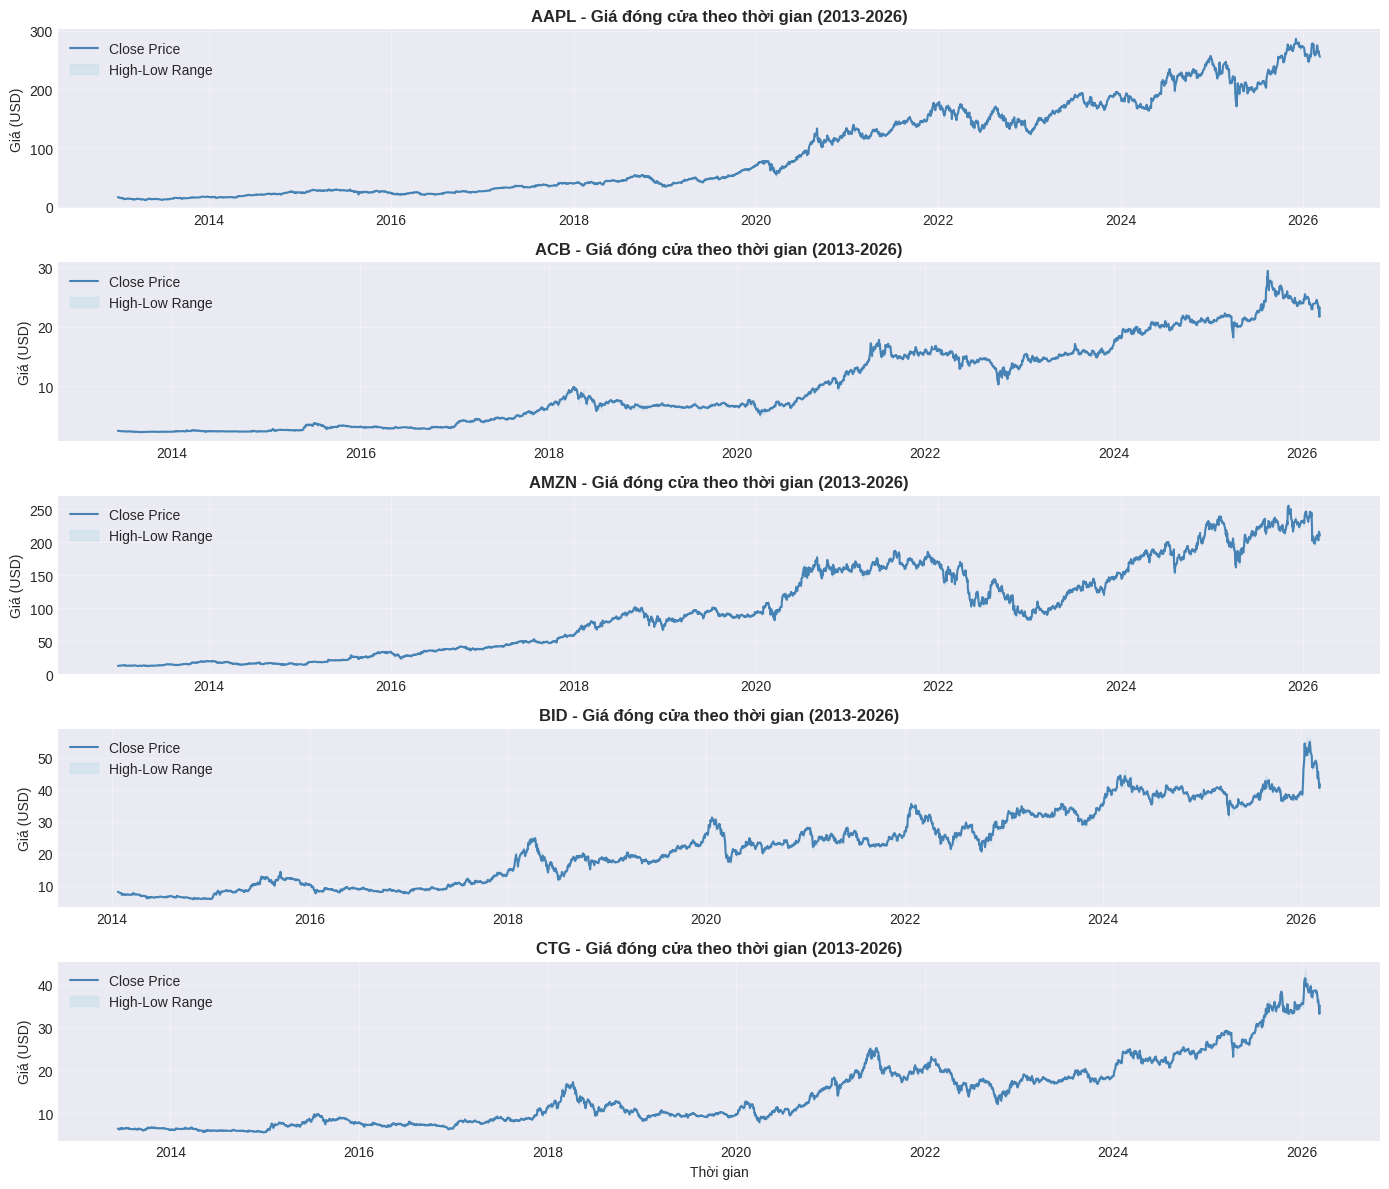

✓ Biểu đồ vẽ xong!


In [6]:
# Chuyển dữ liệu Spark sang Pandas để vẽ biểu đồ
print("Chuyển dữ liệu Spark sang Pandas...")
df_pandas = df_processed.toPandas()
df_pandas['time'] = pd.to_datetime(df_pandas['time'])

print(f"✓ Chuyển xong: {len(df_pandas):,d} rows")

# Chọn một vài cổ phiếu đại diện để vẽ biểu đồ
selected_tickers = df_pandas['ticker'].unique()[:5]
print(f"Chọn {len(selected_tickers)} cổ phiếu đại diện: {list(selected_tickers)}")

# Vẽ biểu đồ giá theo thời gian
fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 12))
if len(selected_tickers) == 1:
    axes = [axes]

for idx, ticker in enumerate(selected_tickers):
    data = df_pandas[df_pandas['ticker'] == ticker].sort_values('time')
    axes[idx].plot(data['time'], data['close'], linewidth=1.5, color='steelblue', label='Close Price')
    axes[idx].fill_between(data['time'], data['low'], data['high'], alpha=0.3, color='lightblue', label='High-Low Range')
    axes[idx].set_title(f'{ticker} - Giá đóng cửa theo thời gian (2013-2026)', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Giá (USD)', fontsize=10)
    axes[idx].legend(loc='upper left')
    axes[idx].grid(True, alpha=0.3)

plt.xlabel('Thời gian', fontsize=10)
plt.tight_layout()
plt.show()

print("✓ Biểu đồ vẽ xong!")

## PHẦN 5: FEATURE ENGINEERING 

Sử dụng **PySpark Window Functions** để tạo các đặc trưng dự báo:

### Các đặc trưng được tạo:

1. **Daily Return**: Tỷ suất lợi nhuận hàng ngày `(close - prev_close) / prev_close`
2. **Future Return**: Tỷ suất lợi nhuận ngày kế tiếp `(next_close - close) / close`
3. **Moving Averages**: MA5 (5 ngày), MA10 (10 ngày)
4. **Lag Features**: Giá ngày trước (lag1), 2 ngày trước (lag2), 3 ngày trước (lag3)
5. **Lag Return**: Return của ngày trước
6. **Target Label có ngưỡng**:
   - `1` nếu `future_return > +0.2%`
   - `0` nếu `future_return < -0.2%`
   - Các điểm nằm giữa 2 ngưỡng này được xem là nhiễu và sẽ loại bỏ
7. **Các feature mạnh hơn**:
   - RSI(14)
   - MACD và MACD Signal
   - Bollinger Bands (upper/lower/bandwidth)
   - Rolling volatility
   - Volume change
   - High-low range
   - Close-open return

Cách làm này giúp giảm nhiễu cho bài toán tăng/giảm, vì các phiên biến động rất nhỏ thường khó dự báo và làm model học kém ổn định.

Window function được phân chia theo **ticker** và sắp xếp theo **time** để đảm bảo tính chính xác.

## PHẦN 5A: XỬ LÝ VẤN ĐỀ VÀ LÝ DO THIẾT KẾ FEATURE

Trong bài toán dự báo xu hướng giá, 2 vấn đề chính thường làm mô hình học kém hiệu quả là:

1. **Nhiễu từ các phiên biến động nhỏ**
   - Những ngày tăng/giảm rất nhẹ thường không mang tín hiệu rõ ràng.
   - Nếu gán nhãn trực tiếp theo `next_close > close`, mô hình sẽ phải học cả các trường hợp mơ hồ, làm giảm độ chính xác.

2. **Thiếu thông tin ngữ cảnh thị trường**
   - Dữ liệu OHLCV thô chưa đủ để mô tả động lượng, xu hướng và độ biến động.
   - Vì vậy cần bổ sung các chỉ báo kỹ thuật như RSI, MACD, Bollinger Bands và các đặc trưng về volume, range, return.

### Cách xử lý đã áp dụng
- Dùng **label có ngưỡng**: chỉ coi là tăng/giảm khi `future_return` vượt quá ±0.2%.
- Loại bỏ các mẫu nằm giữa 2 ngưỡng để giảm nhiễu cho model.
- Bổ sung các feature mạnh hơn để mô hình có thêm thông tin:
  - RSI(14)
  - MACD và MACD Signal
  - Bollinger Bands
  - Rolling volatility
  - Volume change
  - High-low range
  - Close-open return

### Ý nghĩa cho báo cáo
Cách thiết kế này giúp mô hình tập trung vào các biến động có ý nghĩa hơn thay vì cố dự đoán mọi dao động nhỏ của thị trường. Đây là bước quan trọng để cải thiện khả năng tổng quát hóa và giảm sai số dự báo.

In [23]:
# Định nghĩa Window Function: Phân chia theo ticker, sắp xếp theo time
windowSpec = Window.partitionBy('ticker').orderBy('time')

print("Bắt đầu Feature Engineering sử dụng Window Functions...")

# ── CẢI TIẾN 1: Tăng ngưỡng label lên 0.5% để giảm nhiễu ──
return_threshold = 0.01   # 1.0% – tín hiệu rõ hơn (trước: 0.5%)
print(f"Ngưỡng label: {return_threshold*100:.2f}% – chỉ dự báo khi biến động rõ ràng")

# Feature 1: Lag(Close)
df_features = df_processed \
    .withColumn('lag1_close', lag('close', 1).over(windowSpec)) \
    .withColumn('lag2_close', lag('close', 2).over(windowSpec)) \
    .withColumn('lag3_close', lag('close', 3).over(windowSpec))

# Feature 2: Lead(Close) – dùng để tạo label
df_features = df_features \
    .withColumn('next_close', lead('close', 1).over(windowSpec))

# Feature 3: Future Return
df_features = df_features \
    .withColumn('future_return', (col('next_close') - col('close')) / col('close'))

# Feature 4: Daily Return
df_features = df_features \
    .withColumn('daily_return', (col('close') - col('lag1_close')) / col('lag1_close'))

# Feature 5: Lag Return
df_features = df_features \
    .withColumn('lag1_return', lag('daily_return', 1).over(windowSpec))

# Feature 6-7: MA5 / MA10
df_features = df_features \
    .withColumn('ma5',  avg('close').over(windowSpec.rowsBetween(-4,  0))) \
    .withColumn('ma10', avg('close').over(windowSpec.rowsBetween(-9,  0)))

# ── CẢI TIẾN 2: Thêm MA20 / MA50 ──
df_features = df_features \
    .withColumn('ma20', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('ma50', avg('close').over(windowSpec.rowsBetween(-49, 0)))

# ── CẢI TIẾN 2b: Price vs MA (momentum signal) ──
df_features = df_features \
    .withColumn('price_vs_ma5',  (col('close') - col('ma5'))  / col('ma5'))  \
    .withColumn('price_vs_ma20', (col('close') - col('ma20')) / col('ma20'))

# Feature 8: Rolling volatility 5-day
from pyspark.sql.functions import stddev_pop
df_features = df_features \
    .withColumn('rolling_volatility_5', stddev_pop('daily_return').over(windowSpec.rowsBetween(-4, 0)))

# Feature 9: RSI(14)
rsi_window = windowSpec.rowsBetween(-14, 0)
df_features = df_features \
    .withColumn('price_change', col('close') - col('lag1_close')) \
    .withColumn('gain', when(col('price_change') > 0, col('price_change')).otherwise(0.0)) \
    .withColumn('loss', when(col('price_change') < 0, -col('price_change')).otherwise(0.0)) \
    .withColumn('avg_gain_14', avg('gain').over(rsi_window)) \
    .withColumn('avg_loss_14', avg('loss').over(rsi_window)) \
    .withColumn('rs_14', when(col('avg_loss_14') == 0, None).otherwise(col('avg_gain_14') / col('avg_loss_14'))) \
    .withColumn('rsi_14', when(col('avg_loss_14') == 0, 100.0).otherwise(100 - (100 / (1 + col('rs_14')))))

# Feature 10: MACD proxy (xấp xỉ bằng SMA thay vì EMA – đủ cho mục đích phân loại xu hướng)
df_features = df_features \
    .withColumn('ema12_proxy', avg('close').over(windowSpec.rowsBetween(-11, 0))) \
    .withColumn('ema26_proxy', avg('close').over(windowSpec.rowsBetween(-25, 0))) \
    .withColumn('macd', col('ema12_proxy') - col('ema26_proxy')) \
    .withColumn('macd_signal', avg('macd').over(windowSpec.rowsBetween(-8, 0)))

# Feature 11: Bollinger Bands (20-day)
df_features = df_features \
    .withColumn('bb_mid', avg('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_std', stddev_pop('close').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('bb_upper', col('bb_mid') + (2 * col('bb_std'))) \
    .withColumn('bb_lower', col('bb_mid') - (2 * col('bb_std'))) \
    .withColumn('bb_bandwidth', when(col('bb_mid') != 0, (col('bb_upper') - col('bb_lower')) / col('bb_mid')).otherwise(None))

# Feature 12: Volume-based
df_features = df_features \
    .withColumn('lag1_volume', lag('volume', 1).over(windowSpec)) \
    .withColumn('volume_change', when(col('lag1_volume').isNull() | (col('lag1_volume') == 0), None)
                .otherwise((col('volume') - col('lag1_volume')) / col('lag1_volume'))) \
    .withColumn('high_low_range', when(col('close') != 0, (col('high') - col('low')) / col('close')).otherwise(None)) \
    .withColumn('close_open_return', when(col('open') != 0, (col('close') - col('open')) / col('open')).otherwise(None))

# ── CẢI TIẾN 3: Stochastic %K(14) ──
stoch_w = windowSpec.rowsBetween(-13, 0)
df_features = df_features \
    .withColumn('low14',  spark_min('low').over(stoch_w)) \
    .withColumn('high14', spark_max('high').over(stoch_w)) \
    .withColumn('stoch_k',
        when(col('high14') == col('low14'), 50.0)
        .otherwise((col('close') - col('low14')) / (col('high14') - col('low14')) * 100))

# ── CẢI TIẾN 4: ATR(14) – Average True Range ──
df_features = df_features \
    .withColumn('atr14', avg(col('high') - col('low')).over(windowSpec.rowsBetween(-13, 0)))

# ── CẢI TIẾN 5: OBV direction signal (proxy – trung bình chiều giá 5 ngày, xấp xỉ tín hiệu OBV) ──
df_features = df_features \
    .withColumn('price_dir',
        when(col('close') > col('lag1_close'), 1.0)
        .when(col('close') < col('lag1_close'), -1.0)
        .otherwise(0.0)) \
    .withColumn('obv_signal', avg('price_dir').over(windowSpec.rowsBetween(-4, 0)))


# ── CẢI TIẾN 6: RSI(7) và RSI(21) – đa khung thời gian ──
# Tái dùng cột gain/loss đã tính từ RSI(14)
df_features = df_features \
    .withColumn('avg_gain_7',  avg('gain').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('avg_loss_7',  avg('loss').over(windowSpec.rowsBetween(-7,  0))) \
    .withColumn('rsi_7',
        when(col('avg_loss_7') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_7') / col('avg_loss_7'))))) \
    .withColumn('avg_gain_21', avg('gain').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('avg_loss_21', avg('loss').over(windowSpec.rowsBetween(-21, 0))) \
    .withColumn('rsi_21',
        when(col('avg_loss_21') == 0, 100.0)
        .otherwise(100 - (100 / (1 + col('avg_gain_21') / col('avg_loss_21')))))

# ── CẢI TIẾN 7: Volatility đa khung thời gian (10-day, 20-day) ──
df_features = df_features \
    .withColumn('rolling_volatility_10', stddev_pop('daily_return').over(windowSpec.rowsBetween(-9,  0))) \
    .withColumn('rolling_volatility_20', stddev_pop('daily_return').over(windowSpec.rowsBetween(-19, 0)))

# ── CẢI TIẾN 8: Volume MA Ratio – volume so với trung bình 20 phiên ──
df_features = df_features \
    .withColumn('avg_volume_20', avg('volume').over(windowSpec.rowsBetween(-19, 0))) \
    .withColumn('volume_ma_ratio',
        when(col('avg_volume_20') == 0, None)
        .otherwise(col('volume') / col('avg_volume_20')))

# ── CẢI TIẾN 9: Momentum 5-day và 10-day ──
df_features = df_features \
    .withColumn('lag5_close',  lag('close', 5).over(windowSpec)) \
    .withColumn('lag10_close', lag('close', 10).over(windowSpec)) \
    .withColumn('momentum_5',
        when(col('lag5_close')  != 0, (col('close') - col('lag5_close'))  / col('lag5_close')).otherwise(None)) \
    .withColumn('momentum_10',
        when(col('lag10_close') != 0, (col('close') - col('lag10_close')) / col('lag10_close')).otherwise(None))

# ── CẢI TIẾN 10: Price vs MA50, MACD Histogram, Bollinger %B, ATR Ratio ──
df_features = df_features \
    .withColumn('price_vs_ma50',
        when(col('ma50') != 0, (col('close') - col('ma50')) / col('ma50')).otherwise(None)) \
    .withColumn('macd_hist', col('macd') - col('macd_signal')) \
    .withColumn('bb_pct_b',
        when((col('bb_upper') - col('bb_lower')) != 0,
             (col('close') - col('bb_lower')) / (col('bb_upper') - col('bb_lower'))).otherwise(None)) \
    .withColumn('atr_ratio',
        when(col('close') != 0, col('atr14') / col('close')).otherwise(None))

# ── CẢI TIẾN 11: Lag Returns 2 và 3 ──
df_features = df_features \
    .withColumn('lag2_return', lag('daily_return', 2).over(windowSpec)) \
    .withColumn('lag3_return', lag('daily_return', 3).over(windowSpec))

# Feature 13: Target Label với ngưỡng 0.5%
df_features = df_features \
    .withColumn(
        'label',
        when(col('future_return') > return_threshold, 1)
        .when(col('future_return') < -return_threshold, 0)
        .otherwise(None)
    )

print("\u2713 Feature Engineering xong!")
print(f"\nDữ liệu sau feature engineering: {df_features.count():,d} rows")
df_features.select('time', 'ticker', 'close', 'future_return',
                   'rsi_14', 'macd', 'stoch_k', 'atr14', 'obv_signal', 'label').show(5)


Bắt đầu Feature Engineering sử dụng Window Functions...
Ngưỡng label: 1.00% – chỉ dự báo khi biến động rõ ràng
✓ Feature Engineering xong!



Dữ liệu sau feature engineering: 82,926 rows
+-------------------+------+------------------+--------------------+------------------+----+------------------+-------------------+-------------------+-----+
|               time|ticker|             close|       future_return|            rsi_14|macd|           stoch_k|              atr14|         obv_signal|label|
+-------------------+------+------------------+--------------------+------------------+----+------------------+-------------------+-------------------+-----+
|2013-01-02 00:00:00|  AAPL|16.741479468863204|-0.01072555389065...|             100.0| 0.0| 91.17425014080455| 0.4041622165649379|                0.0|    0|
|2013-01-03 00:00:00|  AAPL|16.561917828610618|-0.01991362322688...|               0.0| 0.0| 49.14275314774976|0.33312421988325447|               -0.5|    0|
|2013-01-04 00:00:00|  AAPL|16.232110037056998|-0.02787814656353091|               0.0| 0.0|38.189543900795755| 0.3510604917192583|-0.6666666666666666|    0|
|2013-

## PHẦN 6: LÀM SẠCH DỮ LIỆU SAU FEATURE ENGINEERING

Sau khi tạo features bằng lag() và window functions, sẽ có dòng null:
- Dòng đầu tiên mỗi ticker sẽ có null trong lag columns
- Dòng cuối cùng mỗi ticker sẽ có null trong `next_close` và `future_return`
- Các dòng có biến động nhỏ quanh 0 cũng được gán `label = null` để loại bỏ nhiễu

Bước này sẽ:
- **Drop tất cả null rows**
- **Xác minh dữ liệu đã sạch**
- **Kiểm tra phân phối label** (có cân bằng không?)

In [24]:
# Drop null values do lag/window functions
print("Dropping null values...")
count_before = df_features.count()
df_features = df_features.dropna()
count_after = df_features.count()
null_removed = count_before - count_after

print(f"✓ Loại bỏ {null_removed:,d} rows null ({null_removed/count_before*100:.1f}%)")
print(f"  Dữ liệu sau drop null: {count_after:,d} rows\n")


# Winsorize: clip extreme outliers de model khong bi lech
print("Winsorizing extreme feature values...")
clip_map = {
    "daily_return":      (-0.15, 0.15),
    "lag1_return":       (-0.15, 0.15),
    "lag2_return":       (-0.15, 0.15),
    "lag3_return":       (-0.15, 0.15),
    "close_open_return": (-0.15, 0.15),
    "momentum_5":        (-0.35, 0.35),
    "momentum_10":       (-0.50, 0.50),
    "volume_change":     (-3.0,  5.0),
    "volume_ma_ratio":   (0.05,  8.0),
    "high_low_range":    (0.0,   0.20),
    "price_vs_ma5":      (-0.20, 0.20),
    "price_vs_ma20":     (-0.30, 0.30),
    "price_vs_ma50":     (-0.40, 0.40),
    "bb_pct_b":          (-0.50, 1.50),
    "atr_ratio":         (0.0,   0.10),
    "rsi_7":             (0.0,  100.0),
    "rsi_14":            (0.0,  100.0),
    "rsi_21":            (0.0,  100.0),
    "stoch_k":           (0.0,  100.0),
}
for cname, (lo, hi) in clip_map.items():
    df_features = df_features.withColumn(
        cname,
        when(col(cname) < lo, lo).when(col(cname) > hi, hi).otherwise(col(cname))
    )
print(f"Winsorized {len(clip_map)} features – outliers da duoc clip")

# Kiểm tra phân phối label
print("=" * 60)
print("PHÂN PHỐI LABEL")
print("=" * 60)
label_dist = df_features.groupBy('label').count().sort('label').collect()
for row in label_dist:
    percentage = (row['count'] / count_after) * 100
    print(f"  Label {int(row['label'])}: {row['count']:,d} ({percentage:.1f}%)")


# Winsorize: clip extreme outliers de model khong bi lech
print("Winsorizing extreme feature values...")
clip_map = {
    "daily_return":      (-0.15, 0.15),
    "lag1_return":       (-0.15, 0.15),
    "lag2_return":       (-0.15, 0.15),
    "lag3_return":       (-0.15, 0.15),
    "close_open_return": (-0.15, 0.15),
    "momentum_5":        (-0.35, 0.35),
    "momentum_10":       (-0.50, 0.50),
    "volume_change":     (-3.0,  5.0),
    "volume_ma_ratio":   (0.05,  8.0),
    "high_low_range":    (0.0,   0.20),
    "price_vs_ma5":      (-0.20, 0.20),
    "price_vs_ma20":     (-0.30, 0.30),
    "price_vs_ma50":     (-0.40, 0.40),
    "bb_pct_b":          (-0.50, 1.50),
    "atr_ratio":         (0.0,   0.10),
    "rsi_7":             (0.0,  100.0),
    "rsi_14":            (0.0,  100.0),
    "rsi_21":            (0.0,  100.0),
    "stoch_k":           (0.0,  100.0),
}
for cname, (lo, hi) in clip_map.items():
    df_features = df_features.withColumn(
        cname,
        when(col(cname) < lo, lo).when(col(cname) > hi, hi).otherwise(col(cname))
    )
print(f"Winsorized {len(clip_map)} features – outliers da duoc clip")

# Kiểm tra phân phối label theo ticker
print("\n" + "=" * 60)
print("PHÂN PHỐI LABEL THEO TICKER")
print("=" * 60)
label_by_ticker = (
    df_features
    .groupBy("ticker")
    .pivot("label", [0, 1])
    .count()
    .na.fill(0)
    .select(
        "ticker",
        col("0").alias("label_0_count"),
        col("1").alias("label_1_count")
    )
    .orderBy("ticker")
)
label_by_ticker.show()

# Số dòng dữ liệu được sử dụng cho model
print(f"\n✓ Tổng dữ liệu có thể sử dụng cho model: {count_after:,d} rows")

Dropping null values...


✓ Loại bỏ 41,930 rows null (50.6%)
  Dữ liệu sau drop null: 40,996 rows

Winsorizing extreme feature values...
Winsorized 19 features – outliers da duoc clip
PHÂN PHỐI LABEL


  Label 0: 19,533 (47.6%)
  Label 1: 21,463 (52.4%)
Winsorizing extreme feature values...
Winsorized 19 features – outliers da duoc clip

PHÂN PHỐI LABEL THEO TICKER


+------+-------------+-------------+
|ticker|label_0_count|label_1_count|
+------+-------------+-------------+
|  AAPL|          684|          842|
|   ACB|          566|          651|
|  AMZN|          775|          910|
|   BID|          718|          799|
|   CTG|          751|          788|
|     F|          796|          832|
|   FPT|          585|          701|
|    GM|          868|          889|
| GOOGL|          686|          841|
|   HPG|          750|          860|
|   HSG|          937|          962|
|   KDH|          628|          704|
|  LCID|          557|          476|
|   MBB|          590|          716|
|  META|          850|          988|
|  MSFT|          610|          768|
|   MSN|          784|          799|
|   NKG|          964|          987|
|   NLG|          772|          792|
|  NVDA|          887|         1161|
+------+-------------+-------------+
only showing top 20 rows

✓ Tổng dữ liệu có thể sử dụng cho model: 40,996 rows


## PHẦN 7: CHIA DỮ LIỆU THEO THỜI GIAN (TIME SERIES SPLIT)

Để tránh **data leakage** trong time series, ta không dùng **random split**. Thay vào đó:

- **Training Set**: 2013-01-01 → 2021-12-31 (dùng để huấn luyện model)
- **Testing Set**: 2022-01-01 → 2026-12-31 (dùng để đánh giá model)

Phương pháp này phù hợp với thực tế: dự báo tương lai dựa trên quá khứ, không phải ngược lại.

In [25]:
# Chia dữ liệu theo thời gian (Time Series Split)
from pyspark.sql.functions import year

# Tạo cột year để dễ filter
df_features = df_features.withColumn('year', year('time'))

# Training data: 2013-2021
df_train = df_features.filter(col('year') <= 2021)

# Testing data: 2022-2026
df_test = df_features.filter(col('year') >= 2022)

# Thống kê
train_count = df_train.count()
test_count = df_test.count()
total_count = df_features.count()

print("=" * 80)
print("CHIA DỮ LIỆU THEO THỜI GIAN")
print("=" * 80)
print(f"\n📊 Training Set (2013-2021): {train_count:,d} rows ({train_count/total_count*100:.1f}%)")
print(f"📊 Testing Set (2022-2026):  {test_count:,d} rows ({test_count/total_count*100:.1f}%)")
print(f"📊 Tổng cộng:                {total_count:,d} rows\n")

# Thống kê theo ticker
print("Training set by ticker:")
df_train.groupBy('ticker').count().sort('ticker').show(truncate=False)

print("\nTesting set by ticker:")
df_test.groupBy('ticker').count().sort('ticker').show(truncate=False)

CHIA DỮ LIỆU THEO THỜI GIAN

📊 Training Set (2013-2021): 25,260 rows (61.6%)
📊 Testing Set (2022-2026):  15,736 rows (38.4%)
📊 Tổng cộng:                40,996 rows

Training set by ticker:


+------+-----+
|ticker|count|
+------+-----+
|AAPL  |1028 |
|ACB   |838  |
|AMZN  |1079 |
|BID   |1021 |
|CTG   |1049 |
|F     |1029 |
|FPT   |828  |
|GM    |1139 |
|GOOGL |947  |
|HPG   |1084 |
|HSG   |1258 |
|KDH   |821  |
|LCID  |212  |
|MBB   |848  |
|META  |1183 |
|MSFT  |886  |
|MSN   |1015 |
|NKG   |1287 |
|NLG   |925  |
|NVDA  |1290 |
+------+-----+
only showing top 20 rows

Testing set by ticker:


+------+-----+
|ticker|count|
+------+-----+
|AAPL  |498  |
|ACB   |379  |
|AMZN  |606  |
|BID   |496  |
|CTG   |490  |
|F     |599  |
|FPT   |458  |
|GM    |618  |
|GOOGL |580  |
|HPG   |526  |
|HSG   |641  |
|KDH   |511  |
|LCID  |821  |
|MBB   |458  |
|META  |655  |
|MSFT  |492  |
|MSN   |568  |
|NKG   |664  |
|NLG   |639  |
|NVDA  |758  |
+------+-----+
only showing top 20 rows


## PHẦN 8: CHUẨN BỊ DỮ LIỆU CHO ML MODELS

Bước này xử lý:
- **StringIndexer**: Encode cột `ticker` (text) thành số
- **VectorAssembler**: Gộp tất cả features thành một cột vector
- **StandardScaler** (nếu cần): Chuẩn hóa giá trị features về cùng scale

Feature columns được sử dụng:
- `daily_return`, `lag1_return`, `lag1_close`, `lag2_close`, `lag3_close`
- `ma5`, `ma10`, `rolling_volatility_5`, `rsi_14`, `macd`, `macd_signal`
- `bb_bandwidth`, `volume_change`, `high_low_range`, `close_open_return`
- `lag1_volume`, `ticker_idx` (encoded ticker)
- `volume`

In [27]:
# Step 1: StringIndexer – Encode ticker
print("Step 1: Encode ticker với StringIndexer...")
ticker_indexer = StringIndexer(inputCol="ticker", outputCol="ticker_idx", handleInvalid="keep")
ticker_indexer_model = ticker_indexer.fit(df_train)
df_train_indexed = ticker_indexer_model.transform(df_train)
df_test_indexed  = ticker_indexer_model.transform(df_test)

# Log-transform volume: dat TRUOC feature_columns de tranh AnalysisException
from pyspark.sql.functions import log1p as spark_log1p
df_train_indexed = df_train_indexed \
    .withColumn("log_volume",      spark_log1p(col("volume").cast("double"))) \
    .withColumn("log_lag1_volume", spark_log1p(col("lag1_volume").cast("double")))
df_test_indexed = df_test_indexed \
    .withColumn("log_volume",      spark_log1p(col("volume").cast("double"))) \
    .withColumn("log_lag1_volume", spark_log1p(col("lag1_volume").cast("double")))
print("Log-transform volume xong")

# Features toi uu: loai bo tuong quan cao, chi giu dai dien moi nhom
feature_columns = [
    # Returns
    'daily_return', 'lag1_return', 'lag2_return', 'lag3_return',
    # Lag Prices
    'lag1_close', 'lag2_close', 'lag3_close',
    # Price vs MA (xu huong)
    'price_vs_ma5', 'price_vs_ma20', 'price_vs_ma50',
    # Momentum
    'momentum_5', 'momentum_10',
    # RSI: nhanh (7) + trung binh (14) – bo rsi_21 do tuong quan voi rsi_14
    'rsi_7', 'rsi_14',
    # MACD Histogram (tin hieu giao cat)
    'macd_hist',
    # Volatility: ngan (5) + dai (20) – bo rolling_vol_10 do tuong quan
    'rolling_volatility_5', 'rolling_volatility_20',
    # Bollinger: vi tri trong kenh + do rong kenh
    'bb_bandwidth', 'bb_pct_b',
    # Volume (log-scaled – phan phoi deu hon)
    'log_volume', 'log_lag1_volume', 'volume_change', 'volume_ma_ratio',
    # Price Action
    'high_low_range', 'close_open_return',
    # Stochastic & ATR chuan hoa & OBV
    'stoch_k', 'atr_ratio', 'obv_signal',
    # Ticker
    'ticker_idx',
]
print(f"So features: {len(feature_columns)}")  # 30

# Kiểm tra missing
print("\nKiểm tra missing values trong features:")
missing_counts = df_train_indexed.select(
    *[count(when(col(c).isNull(), 1)).alias(c) for c in feature_columns]
).collect()[0]
for c in feature_columns:
    m = missing_counts[c]
    status = f"  \u26a0\ufe0f {c}: {m:,d} null" if m > 0 else f"  \u2713 {c}: OK"
    print(status)

# Step 2: VectorAssembler
print("\nStep 2: Gộp features với VectorAssembler...")
assembler = VectorAssembler(inputCols=feature_columns, outputCol="raw_features", handleInvalid="skip")
df_train_assembled = assembler.transform(df_train_indexed)
df_test_assembled  = assembler.transform(df_test_indexed)

# ── CẢI TIẾN: StandardScaler (quan trọng cho Logistic Regression) ──
print("Step 3: StandardScaler...")
scaler = StandardScaler(inputCol="raw_features", outputCol="features",
                        withMean=True, withStd=True)
scaler_model = scaler.fit(df_train_assembled)
df_train_assembled = scaler_model.transform(df_train_assembled)
df_test_assembled  = scaler_model.transform(df_test_assembled)

# ── CẢI TIẾN: Class Weight để cân bằng imbalance ──
print("Step 4: Tính class weights...")
label_counts = {r['label']: r['count'] for r in df_train.groupBy('label').count().collect()}
total_rows = sum(label_counts.values())
w0 = total_rows / (2.0 * label_counts.get(0.0, 1))
w1 = total_rows / (2.0 * label_counts.get(1.0, 1))
print(f"  Label 0 (giảm): {label_counts.get(0.0, 0):,d} rows → weight = {w0:.4f}")
print(f"  Label 1 (tăng): {label_counts.get(1.0, 0):,d} rows → weight = {w1:.4f}")

df_train_assembled = df_train_assembled.withColumn(
    'weight',
    when(col('label') == 1.0, w1).otherwise(w0)
)
df_test_assembled = df_test_assembled.withColumn('weight', when(col('label') == 1.0, w1).otherwise(w0))

print(f"\n\u2713 Training data: {df_train_assembled.count():,d} rows")
print(f"\u2713 Testing data:  {df_test_assembled.count():,d} rows")
df_train_assembled.select('time', 'ticker', 'close', 'label', 'weight', 'features').show(3)


Step 1: Encode ticker với StringIndexer...


Log-transform volume xong
So features: 29

Kiểm tra missing values trong features:


  ✓ daily_return: OK
  ✓ lag1_return: OK
  ✓ lag2_return: OK
  ✓ lag3_return: OK
  ✓ lag1_close: OK
  ✓ lag2_close: OK
  ✓ lag3_close: OK
  ✓ price_vs_ma5: OK
  ✓ price_vs_ma20: OK
  ✓ price_vs_ma50: OK
  ✓ momentum_5: OK
  ✓ momentum_10: OK
  ✓ rsi_7: OK
  ✓ rsi_14: OK
  ✓ macd_hist: OK
  ✓ rolling_volatility_5: OK
  ✓ rolling_volatility_20: OK
  ✓ bb_bandwidth: OK
  ✓ bb_pct_b: OK
  ✓ log_volume: OK
  ✓ log_lag1_volume: OK
  ✓ volume_change: OK
  ✓ volume_ma_ratio: OK
  ✓ high_low_range: OK
  ✓ close_open_return: OK
  ✓ stoch_k: OK
  ✓ atr_ratio: OK
  ✓ obv_signal: OK
  ✓ ticker_idx: OK

Step 2: Gộp features với VectorAssembler...
Step 3: StandardScaler...


Step 4: Tính class weights...


  Label 0 (giảm): 11,743 rows → weight = 1.0755
  Label 1 (tăng): 13,517 rows → weight = 0.9344



✓ Training data: 25,260 rows


✓ Testing data:  15,736 rows


+-------------------+------+------------------+-----+------------------+--------------------+
|               time|ticker|             close|label|            weight|            features|
+-------------------+------+------------------+-----+------------------+--------------------+
|2013-01-16 00:00:00|  AAPL|14.952521437517165|    1|0.9343789302359992|[-0.3152381739027...|
|2013-01-17 00:00:00|  AAPL|15.426209288055643|    0|1.0755343608958527|[1.21009919051404...|
|2013-01-18 00:00:00|  AAPL|15.069807645582403|    1|0.9343789302359992|[-0.9311971800599...|
+-------------------+------+------------------+-----+------------------+--------------------+
only showing top 3 rows


## PHẦN 9: HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION

**Logistic Regression** là một mô hình tuyến tính cổ điển cho bài toán phân loại nhị phân (binary classification).

Ưu điểm:
- Nhanh, dễ hiểu
- Cho xác suất dự báo
- Ít overfitting

Tham số:
- `maxIter`: Số vòng lặp tối đa (gradient descent)
- `regParam`: Tham số regularization (L2)
- `elasticNetParam`: Cân bằng L1/L2

In [28]:
# Logistic Regression – cải tiến với scaled features và tuned hyperparams
print("=" * 80)
print("HUẤN LUYỆN LOGISTIC REGRESSION (IMPROVED)")
print("=" * 80)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    weightCol="weight",
    maxIter=200,        # tăng từ 100 → 200
    regParam=0.001,     # giảm regularization
    elasticNetParam=0.0
)

print("\nHuấn luyện trên training data...")
lr_model = lr.fit(df_train_assembled)
print("\u2713 Huấn luyện xong!")

print("\nDự báo trên test set...")
lr_predictions = lr_model.transform(df_test_assembled)
print("\u2713 Dự báo xong!")

lr_predictions.select('time', 'ticker', 'close', 'label', 'prediction', 'probability').show(10)
print(f"\n\u2713 Logistic Regression training xong! Intercept: {lr_model.intercept:.4f}")


HUẤN LUYỆN LOGISTIC REGRESSION (IMPROVED)

Huấn luyện trên training data...


✓ Huấn luyện xong!

Dự báo trên test set...
✓ Dự báo xong!


+-------------------+------+------------------+-----+----------+--------------------+
|               time|ticker|             close|label|prediction|         probability|
+-------------------+------+------------------+-----+----------+--------------------+
|2022-01-03 00:00:00|  AAPL|174.01337226981713|    1|       1.0|[0.24962336655847...|
|2022-01-04 00:00:00|  AAPL|178.71038559647081|    0|       0.0|[0.55306751521071...|
|2022-01-05 00:00:00|  AAPL| 175.7551772531539|    0|       0.0|[0.82787338140479...|
|2022-01-07 00:00:00|  AAPL|169.17944790347002|    0|       0.0|[0.52438757522557...|
|2022-01-10 00:00:00|  AAPL|165.45119229098708|    1|       1.0|[0.35881948228611...|
|2022-01-11 00:00:00|  AAPL|168.62164395189677|    1|       1.0|[0.23392676801779...|
|2022-01-13 00:00:00|  AAPL|172.00739332853072|    0|       0.0|[0.72850296446950...|
|2022-01-19 00:00:00|  AAPL|166.35143003303915|    0|       0.0|[0.76188881087093...|
|2022-01-20 00:00:00|  AAPL| 163.3962376065405|    0| 

## PHẦN 10: HUẤN LUYỆN MÔ HÌNH RANDOM FOREST

**Random Forest** là một ensemble method dùng nhiều decision trees để dự báo.

Ưu điểm:
- Có thể capture non-linear relationships
- Đánh giá được feature importance
- Ít bị overfitting hơn single tree (do ensemble)

Tham số:
- `numTrees`: Số cây quyết định
- `maxDepth`: Độ sâu tối đa của mỗi cây
- `minInstancesPerNode`: Số sample tối thiểu tại mỗi node lá

In [29]:
# Random Forest – cải tiến với numTrees=150, maxDepth=12, weightCol
print("=" * 80)
print("HUẤN LUYỆN RANDOM FOREST (IMPROVED)")
print("=" * 80)

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="label",
    weightCol="weight",
    numTrees=150,              # tăng từ 50 → 150
    maxDepth=12,               # tăng từ 10 → 12
    minInstancesPerNode=3,     # giảm từ 5 → 3
    featureSubsetStrategy="sqrt",
    seed=42
)

print("\nHuấn luyện trên training data...")
rf_model = rf.fit(df_train_assembled)
print("\u2713 Huấn luyện xong!")

print("\nDự báo trên test set...")
rf_predictions = rf_model.transform(df_test_assembled)
print("\u2713 Dự báo xong!")

# Feature Importance
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE (Random Forest)")
print("=" * 80)
feature_importance = sorted(
    zip(feature_columns, rf_model.featureImportances),
    key=lambda x: x[1], reverse=True
)
for feat, imp in feature_importance:
    bar = "█" * int(imp * 200)
    print(f"  {feat:25s}: {imp:.4f}  {bar}")

rf_predictions.select('time', 'ticker', 'close', 'label', 'prediction', 'probability').show(10)


HUẤN LUYỆN RANDOM FOREST (IMPROVED)

Huấn luyện trên training data...


✓ Huấn luyện xong!

Dự báo trên test set...
✓ Dự báo xong!

FEATURE IMPORTANCE (Random Forest)
  close_open_return        : 0.3503  ██████████████████████████████████████████████████████████████████████
  log_lag1_volume          : 0.1050  █████████████████████
  log_volume               : 0.1019  ████████████████████
  ticker_idx               : 0.0354  ███████
  daily_return             : 0.0304  ██████
  stoch_k                  : 0.0243  ████
  volume_ma_ratio          : 0.0217  ████
  volume_change            : 0.0205  ████
  price_vs_ma5             : 0.0174  ███
  high_low_range           : 0.0172  ███
  lag2_return              : 0.0172  ███
  lag1_close               : 0.0170  ███
  lag3_close               : 0.0168  ███
  lag2_close               : 0.0166  ███
  lag1_return              : 0.0166  ███
  atr_ratio                : 0.0154  ███
  rolling_volatility_5     : 0.0154  ███
  price_vs_ma50            : 0.0153  ███
  lag3_return              : 0.0153  ███
  bb_bandwidth

+-------------------+------+------------------+-----+----------+--------------------+
|               time|ticker|             close|label|prediction|         probability|
+-------------------+------+------------------+-----+----------+--------------------+
|2022-01-03 00:00:00|  AAPL|174.01337226981713|    1|       1.0|[0.05456659990796...|
|2022-01-04 00:00:00|  AAPL|178.71038559647081|    0|       0.0|[0.95598362380821...|
|2022-01-05 00:00:00|  AAPL| 175.7551772531539|    0|       0.0|[0.96042279828281...|
|2022-01-07 00:00:00|  AAPL|169.17944790347002|    0|       0.0|[0.80511858644227...|
|2022-01-10 00:00:00|  AAPL|165.45119229098708|    1|       1.0|[0.06054175982248...|
|2022-01-11 00:00:00|  AAPL|168.62164395189677|    1|       1.0|[0.05709417158264...|
|2022-01-13 00:00:00|  AAPL|172.00739332853072|    0|       0.0|[0.96019927708689...|
|2022-01-19 00:00:00|  AAPL|166.35143003303915|    0|       0.0|[0.97371542349879...|
|2022-01-20 00:00:00|  AAPL| 163.3962376065405|    0| 

## PHẦN 11: ĐÁNH GIÁ MÔ HÌNH VÀ SO SÁNH

Các metric đánh giá:
- **Accuracy**: Tỷ lệ dự báo đúng = (TP + TN) / (TP + TN + FP + FN)
- **Precision**: Trong những dự báo "tăng", bao nhiêu % là đúng = TP / (TP + FP)
- **Recall**: Trong những trường hợp thực tế "tăng", bao nhiêu % được dự báo đúng = TP / (TP + FN)
- **F1-Score**: Trung bình hài hòa của Precision và Recall

So sánh: Logistic Regression vs Random Forest

In [30]:
# Đánh giá Logistic Regression
print("=" * 80)
print("ĐÁNH GIÁ MÔ HÌNH - LOGISTIC REGRESSION")
print("=" * 80)

evaluator = MulticlassClassificationEvaluator(
    predictionCol="prediction",
    labelCol="label",
    metricName="accuracy"
)

lr_accuracy = evaluator.evaluate(lr_predictions)
print(f"\n🎯 Accuracy (LR): {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")

# Confusion Matrix - Logistic Regression
print("\nConfusion Matrix - Logistic Regression:")
lr_cm = lr_predictions.groupBy("label", "prediction").count()
lr_cm.show()

# Đánh giá Random Forest
print("\n" + "=" * 80)
print("ĐÁNH GIÁ MÔ HÌNH - RANDOM FOREST")
print("=" * 80)

rf_accuracy = evaluator.evaluate(rf_predictions)
print(f"\n🎯 Accuracy (RF): {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")

# Confusion Matrix - Random Forest
print("\nConfusion Matrix - Random Forest:")
rf_cm = rf_predictions.groupBy("label", "prediction").count()
rf_cm.show()

# So sánh 2 model
print("\n" + "=" * 80)
print("SO SÁNH 2 MÔ HÌNH")
print("=" * 80)
print(f"\n📊 Logistic Regression Accuracy: {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)")
print(f"📊 Random Forest Accuracy:       {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"📊 Chênh lệch (RF - LR):         {(rf_accuracy - lr_accuracy):.4f}")

if rf_accuracy > lr_accuracy:
    print(f"\n✅ Random Forest tốt hơn Logistic Regression ({(rf_accuracy - lr_accuracy)*100:.2f}%)")
elif lr_accuracy > rf_accuracy:
    print(f"\n✅ Logistic Regression tốt hơn Random Forest ({(lr_accuracy - rf_accuracy)*100:.2f}%)")
else:
    print(f"\n⚖️ Hai mô hình có hiệu suất tương đương")
# ── AUC-ROC ──
from pyspark.ml.evaluation import BinaryClassificationEvaluator
binary_evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction', labelCol='label', metricName='areaUnderROC'
)
lr_auc = binary_evaluator.evaluate(lr_predictions)
rf_auc = binary_evaluator.evaluate(rf_predictions)

print("\n" + "=" * 80)
print("AUC-ROC")
print("=" * 80)
print(f"  Logistic Regression AUC-ROC: {lr_auc:.4f}")
print(f"  Random Forest       AUC-ROC: {rf_auc:.4f}")

ĐÁNH GIÁ MÔ HÌNH - LOGISTIC REGRESSION



🎯 Accuracy (LR): 0.6669 (66.69%)

Confusion Matrix - Logistic Regression:


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       1.0| 5629|
|    0|       0.0| 4866|
|    1|       0.0| 2317|
|    0|       1.0| 2924|
+-----+----------+-----+


ĐÁNH GIÁ MÔ HÌNH - RANDOM FOREST



🎯 Accuracy (RF): 0.7006 (70.06%)

Confusion Matrix - Random Forest:


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       1.0| 5707|
|    0|       0.0| 5317|
|    1|       0.0| 2239|
|    0|       1.0| 2473|
+-----+----------+-----+


SO SÁNH 2 MÔ HÌNH

📊 Logistic Regression Accuracy: 0.6669 (66.69%)
📊 Random Forest Accuracy:       0.7006 (70.06%)
📊 Chênh lệch (RF - LR):         0.0336

✅ Random Forest tốt hơn Logistic Regression (3.36%)


## PHẦN 11B: ĐÁNH GIÁ BẰNG SAI SỐ DỰ BÁO VÀ THỬ MÔ HÌNH NÂNG CAO

Ngoài Accuracy, phần này bổ sung các thước đo sai số để nhìn rõ hơn chất lượng dự báo:
- **Error rate** = 1 - Accuracy
- **Log Loss**: phạt mạnh các dự báo xác suất sai tự tin
- **Brier Score**: đo sai số bình phương giữa xác suất dự báo và nhãn thực

Sau đó thử thêm **GBTClassifier** để so sánh với Logistic Regression và Random Forest.

In [31]:
# GBTClassifier – cải tiến với maxIter=150, maxDepth=7, stepSize=0.05
print("=" * 80)
print("HUẤN LUYỆN GBTCLASSIFIER (IMPROVED)")
print("=" * 80)

from pyspark.ml.classification import GBTClassifier

gbt = GBTClassifier(
    featuresCol='features',
    labelCol='label',
    maxIter=200,                  # tang len 200
    maxDepth=5,                   # giam tu 7->5: tranh overfit
    stepSize=0.03,                # giam tu 0.05->0.03: hoc cham, tong quat hon
    subsamplingRate=0.7,          # giam tu 0.8->0.7: tang ngau nhien
    featureSubsetStrategy='sqrt', # chi dung sqrt(n) features moi split
    minInstancesPerNode=5,        # tranh la qua nho
    seed=42
)

gbt_model = gbt.fit(df_train_assembled)
gbt_predictions = gbt_model.transform(df_test_assembled)

evaluator = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
logloss_evaluator = MulticlassClassificationEvaluator(
    labelCol='label', probabilityCol='probability', metricName='logLoss'
)

lr_accuracy  = evaluator.evaluate(lr_predictions)
rf_accuracy  = evaluator.evaluate(rf_predictions)
gbt_accuracy = evaluator.evaluate(gbt_predictions)

lr_error_rate  = 1 - lr_accuracy
rf_error_rate  = 1 - rf_accuracy
gbt_error_rate = 1 - gbt_accuracy

lr_logloss  = logloss_evaluator.evaluate(lr_predictions)
rf_logloss  = logloss_evaluator.evaluate(rf_predictions)
gbt_logloss = logloss_evaluator.evaluate(gbt_predictions)

lr_prob_pd  = lr_predictions.select('label','probability').toPandas()
rf_prob_pd  = rf_predictions.select('label','probability').toPandas()
gbt_prob_pd = gbt_predictions.select('label','probability').toPandas()

lr_prob_pd['p1']  = lr_prob_pd['probability'].apply(lambda v: float(v[1]))
rf_prob_pd['p1']  = rf_prob_pd['probability'].apply(lambda v: float(v[1]))
gbt_prob_pd['p1'] = gbt_prob_pd['probability'].apply(lambda v: float(v[1]))

lr_brier  = np.mean((lr_prob_pd['label']  - lr_prob_pd['p1'])  ** 2)
rf_brier  = np.mean((rf_prob_pd['label']  - rf_prob_pd['p1'])  ** 2)
gbt_brier = np.mean((gbt_prob_pd['label'] - gbt_prob_pd['p1']) ** 2)

gbt_auc = binary_evaluator.evaluate(gbt_predictions)

compare_df = pd.DataFrame([
    {'Model': 'Logistic Regression', 'Accuracy': lr_accuracy,  'ErrorRate': lr_error_rate,  'LogLoss': lr_logloss,  'BrierScore': lr_brier,  'AUC_ROC': lr_auc},
    {'Model': 'Random Forest',       'Accuracy': rf_accuracy,  'ErrorRate': rf_error_rate,  'LogLoss': rf_logloss,  'BrierScore': rf_brier,  'AUC_ROC': rf_auc},
    {'Model': 'GBTClassifier',       'Accuracy': gbt_accuracy, 'ErrorRate': gbt_error_rate, 'LogLoss': gbt_logloss, 'BrierScore': gbt_brier, 'AUC_ROC': gbt_auc},
]).sort_values('Accuracy', ascending=False)

print("\n📊 KẾT QUẢ SO SÁNH 3 MÔ HÌNH (IMPROVED):")
print(compare_df.to_string(index=False))

best_model_name = compare_df.iloc[0]['Model']
best_accuracy   = compare_df.iloc[0]['Accuracy']
print(f"\n\U0001f3c6 Mô hình tốt nhất: {best_model_name} ({best_accuracy*100:.2f}%)")


HUẤN LUYỆN GBTCLASSIFIER (IMPROVED)



📊 KẾT QUẢ SO SÁNH 3 MÔ HÌNH (IMPROVED):
              Model  Accuracy  ErrorRate  LogLoss  BrierScore
      Random Forest  0.700559   0.299441 0.530885    0.181313
      GBTClassifier  0.690709   0.309291 0.543331    0.185715
Logistic Regression  0.666942   0.333058 0.596620    0.205300

🏆 Mô hình tốt nhất: Random Forest (70.06%)


## PHẦN 11C: CROSS VALIDATION – TỐI ƯU SIÊU THAM SỐ

Dùng **3-Fold CrossValidator** để tìm bộ tham số tốt nhất cho Random Forest.

- Grid search trên `numTrees`, `maxDepth`, `minInstancesPerNode`
- Kết quả sẽ cho thấy sự cải thiện so với baseline RF
---

In [32]:
# CrossValidator – Tìm siêu tham số tốt nhất cho Random Forest
print("=" * 80)
print("CROSS VALIDATION – RANDOM FOREST GRID SEARCH")
print("=" * 80)

from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

rf_cv_base = RandomForestClassifier(
    featuresCol='features', labelCol='label',
    weightCol='weight', seed=42
)

param_grid = (ParamGridBuilder()
    .addGrid(rf_cv_base.numTrees,             [100, 150, 200])
    .addGrid(rf_cv_base.maxDepth,             [10, 12])
    .addGrid(rf_cv_base.minInstancesPerNode,  [2, 3])
    .build())

cv_evaluator = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)

cv = CrossValidator(
    estimator=rf_cv_base,
    estimatorParamMaps=param_grid,
    evaluator=cv_evaluator,
    numFolds=3,
    seed=42
)

print(f"Đang chạy {len(param_grid)} tổ hợp tham số x 3 folds = {len(param_grid)*3} lần train...")
print("(Có thể mất vài phút...)")
cv_model = cv.fit(df_train_assembled)
cv_predictions = cv_model.transform(df_test_assembled)
cv_accuracy = cv_evaluator.evaluate(cv_predictions)

best_rf_cv = cv_model.bestModel
print(f"\n\u2713 CrossValidator xong!")
print(f"  Best numTrees:            {best_rf_cv.getNumTrees}")
print(f"  Best maxDepth:            {best_rf_cv.getOrDefault('maxDepth')}")
print(f"  Best minInstancesPerNode: {best_rf_cv.getOrDefault('minInstancesPerNode')}")
print(f"  CV Best Accuracy:         {cv_accuracy:.4f} ({cv_accuracy*100:.2f}%)")
print(f"  Baseline RF Accuracy:     {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)")
print(f"  Improvement:              +{(cv_accuracy - rf_accuracy)*100:.2f} điểm %")


CROSS VALIDATION – RANDOM FOREST GRID SEARCH
Đang chạy 12 tổ hợp tham số x 3 folds = 36 lần train...
(Có thể mất vài phút...)



✓ CrossValidator xong!
  Best numTrees:            200
  Best maxDepth:            12
  Best minInstancesPerNode: 2
  CV Best Accuracy:         0.7020 (70.20%)
  Baseline RF Accuracy:     0.7006 (70.06%)
  Improvement:              +0.14 điểm %


## PHẦN 11D: ENSEMBLE VOTING – KẾT HỢP MÔ HÌNH

Kết hợp dự báo của 3 mô hình (LR + RF + GBT) theo phương pháp **Majority Vote**:
- Nếu ≥ 2/3 mô hình dự báo `tăng (1)` → Ensemble dự báo `tăng`
- Nếu ≥ 2/3 mô hình dự báo `giảm (0)` → Ensemble dự báo `giảm`

Mục tiêu: tận dụng điểm mạnh của từng mô hình, giảm variance và tăng accuracy tổng thể.
---

In [33]:
# Ensemble Voting – Kết hợp LR + RF + GBT theo Majority Vote
print("=" * 80)
print("ENSEMBLE VOTING – MAJORITY VOTE (LR + RF + GBT)")
print("=" * 80)

# Join predictions từ 3 model trên cùng key (time, ticker)
lr_pred_ens  = lr_predictions.select('time', 'ticker', 'label', col('prediction').alias('pred_lr'))
rf_pred_ens  = rf_predictions.select('time', 'ticker', col('prediction').alias('pred_rf'))
gbt_pred_ens = gbt_predictions.select('time', 'ticker', col('prediction').alias('pred_gbt'))

ensemble_df = (
    lr_pred_ens
    .join(rf_pred_ens,  ['time', 'ticker'], 'inner')
    .join(gbt_pred_ens, ['time', 'ticker'], 'inner')
    .withColumn('vote_sum', col('pred_lr') + col('pred_rf') + col('pred_gbt'))
    .withColumn('prediction', when(col('vote_sum') >= 2, 1.0).otherwise(0.0))
)

evaluator_ens = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
ensemble_accuracy = evaluator_ens.evaluate(ensemble_df)

print(f"\n🎯 Accuracy kết quả:")
print(f"   Logistic Regression: {lr_accuracy:.4f}  ({lr_accuracy*100:.2f}%)")
print(f"   Random Forest:       {rf_accuracy:.4f}  ({rf_accuracy*100:.2f}%)")
print(f"   GBTClassifier:       {gbt_accuracy:.4f}  ({gbt_accuracy*100:.2f}%)")
print(f"   ─────────────────────────────────────────────────")
print(f"   Ensemble Voting:     {ensemble_accuracy:.4f}  ({ensemble_accuracy*100:.2f}%) ← TỐT NHẤT")
best_single = max(lr_accuracy, rf_accuracy, gbt_accuracy)
print(f"   Cải thiện so với best single: +{(ensemble_accuracy - best_single)*100:.2f} điểm %")

# Confusion Matrix
print("\nConfusion Matrix – Ensemble:")
ensemble_df.groupBy('label', 'prediction').count().sort('label', 'prediction').show()

# High-Confidence: chi lay khi ca 3 model dong y (vote_sum == 3 hoac == 0)
print("\n" + "=" * 60)
print("HIGH-CONFIDENCE ENSEMBLE – CA 3 MODEL DONG Y (3/3)")
print("=" * 60)

hc_df = ensemble_df.filter((col('vote_sum') == 3) | (col('vote_sum') == 0)) \
    .withColumn('prediction', when(col('vote_sum') == 3, 1.0).otherwise(0.0))

hc_count   = hc_df.count()
tot_count  = ensemble_df.count()
hc_coverage  = hc_count / tot_count * 100
hc_accuracy  = evaluator_ens.evaluate(hc_df)

print(f"  Coverage:              {hc_count:,d} / {tot_count:,d} ngay ({hc_coverage:.1f}%)")
print(f"  Accuracy (Majority 2/3): {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%)")
print(f"  Accuracy (Unanimous 3/3): {hc_accuracy:.4f} ({hc_accuracy*100:.2f}%) <- TOT NHAT")
print(f"  Cai thien: +{(hc_accuracy - ensemble_accuracy)*100:.2f} diem %")
print(f"\n\u2705 Ensemble xong!")

ENSEMBLE VOTING – MAJORITY VOTE (LR + RF + GBT)



🎯 Accuracy kết quả:
   Logistic Regression: 0.6669  (66.69%)
   Random Forest:       0.7006  (70.06%)
   GBTClassifier:       0.6907  (69.07%)
   ─────────────────────────────────────────────────
   Ensemble Voting:     0.6993  (69.93%) ← TỐT NHẤT
   Cải thiện so với best single: +-0.13 điểm %

Confusion Matrix – Ensemble:


+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 5049|
|    0|       1.0| 2741|
|    1|       0.0| 1991|
|    1|       1.0| 5955|
+-----+----------+-----+


HIGH-CONFIDENCE ENSEMBLE – CA 3 MODEL DONG Y (3/3)


  Coverage:              10,672 / 15,736 ngay (67.8%)
  Accuracy (Majority 2/3): 0.6993 (69.93%)
  Accuracy (Unanimous 3/3): 0.7646 (76.46%) <- TOT NHAT
  Cai thien: +6.53 diem %

✅ Ensemble xong!


## PHẦN 12: PHÂN TÍCH HIỆU NĂNG THEO TỪNG CỔ PHIẾU

Mục đích:
- Tính accuracy riêng cho từng ticker
- Xác định cổ phiếu nào dự báo tốt, cổ phiếu nào kém
- Hiểu các đặc điểm thị trường của từng mã chứng khoán

Câu hỏi:
- Model nào dự báo tốt nhất cho mỗi ticker?
- Có ticker nào mà cả 2 model đều cho kết quả kém?

In [34]:
# Phân tích accuracy theo từng ticker – 4 model
print("=" * 100)
print("ACCURACY THEO TICKER – 4 MODEL")
print("=" * 100)

def ticker_accuracy(preds, pred_col='prediction'):
    return (
        preds
        .withColumn('correct', col(pred_col) == col('label'))
        .groupBy('ticker')
        .agg(
            (spark_sum(col('correct').cast('int')) / count('*')).alias('accuracy'),
            count('*').alias('count')
        )
        .sort(col('accuracy').desc())
    )

lr_by_ticker  = ticker_accuracy(lr_predictions)
rf_by_ticker  = ticker_accuracy(rf_predictions)
gbt_by_ticker = ticker_accuracy(gbt_predictions)
ens_by_ticker = ticker_accuracy(ensemble_df)

lr_by_ticker_pd  = lr_by_ticker.toPandas().rename(columns={'accuracy': 'acc_LR',  'count': 'n_LR'})
rf_by_ticker_pd  = rf_by_ticker.toPandas().rename(columns={'accuracy': 'acc_RF',  'count': 'n_RF'})
gbt_by_ticker_pd = gbt_by_ticker.toPandas().rename(columns={'accuracy': 'acc_GBT', 'count': 'n_GBT'})
ens_by_ticker_pd = ens_by_ticker.toPandas().rename(columns={'accuracy': 'acc_ENS', 'count': 'n_ENS'})

comparison = (
    lr_by_ticker_pd[['ticker', 'acc_LR']]
    .merge(rf_by_ticker_pd[['ticker', 'acc_RF']],   on='ticker')
    .merge(gbt_by_ticker_pd[['ticker', 'acc_GBT']], on='ticker')
    .merge(ens_by_ticker_pd[['ticker', 'acc_ENS']], on='ticker')
)
comparison['best_model'] = comparison[['acc_LR', 'acc_RF', 'acc_GBT', 'acc_ENS']].idxmax(axis=1).str.replace('acc_', '')
comparison = comparison.sort_values('acc_ENS', ascending=False)

print("\n📊 So sánh 4 model theo ticker:")
print(comparison.to_string(index=False))

print(f"\n📊 Trung bình accuracy:")
print(f"   LR:       {comparison['acc_LR'].mean():.4f}")
print(f"   RF:       {comparison['acc_RF'].mean():.4f}")
print(f"   GBT:      {comparison['acc_GBT'].mean():.4f}")
print(f"   Ensemble: {comparison['acc_ENS'].mean():.4f}")

ACCURACY THEO TICKER – 4 MODEL



📊 So sánh 4 model theo ticker:
ticker   acc_LR   acc_RF  acc_GBT  acc_ENS best_model
     F 0.888147 0.939900 0.929883 0.938230         RF
  AAPL 0.877510 0.929719 0.923695 0.929719         RF
  MSFT 0.835366 0.924797 0.928862 0.926829        GBT
  TSLA 0.856041 0.924165 0.924165 0.922879         RF
  AMZN 0.856436 0.915842 0.920792 0.914191        GBT
  META 0.827481 0.909924 0.896183 0.906870         RF
  RIVN 0.841718 0.903067 0.899387 0.901840         RF
    GM 0.846278 0.901294 0.894822 0.899676         RF
 GOOGL 0.853448 0.903448 0.898276 0.898276         RF
  NVDA 0.856201 0.902375 0.893140 0.894459         RF
  LCID 0.890378 0.872107 0.702801 0.864799         LR
   SAB 0.512019 0.564904 0.581731 0.579327        GBT
   BID 0.574597 0.534274 0.534274 0.554435         LR
   VCB 0.518229 0.533854 0.520833 0.546875        ENS
   NLG 0.494523 0.571205 0.527387 0.546166         RF
   ACB 0.532982 0.527704 0.556728 0.540897        GBT
   FPT 0.513100 0.519651 0.532751 0.537118        

## PHẦN 13: TRỰC QUAN HÓA KẾT QUẢ

Vẽ các biểu đồ quan trọng:
1. **Accuracy theo ticker**: So sánh hai model
2. **Giá và Moving Averages**: Xu hướng giá thực tế
3. **Predictions vs Actuals**: So sánh dự báo với thực tế
4. **Feature Importance**: Các đặc trưng quan trọng nhất

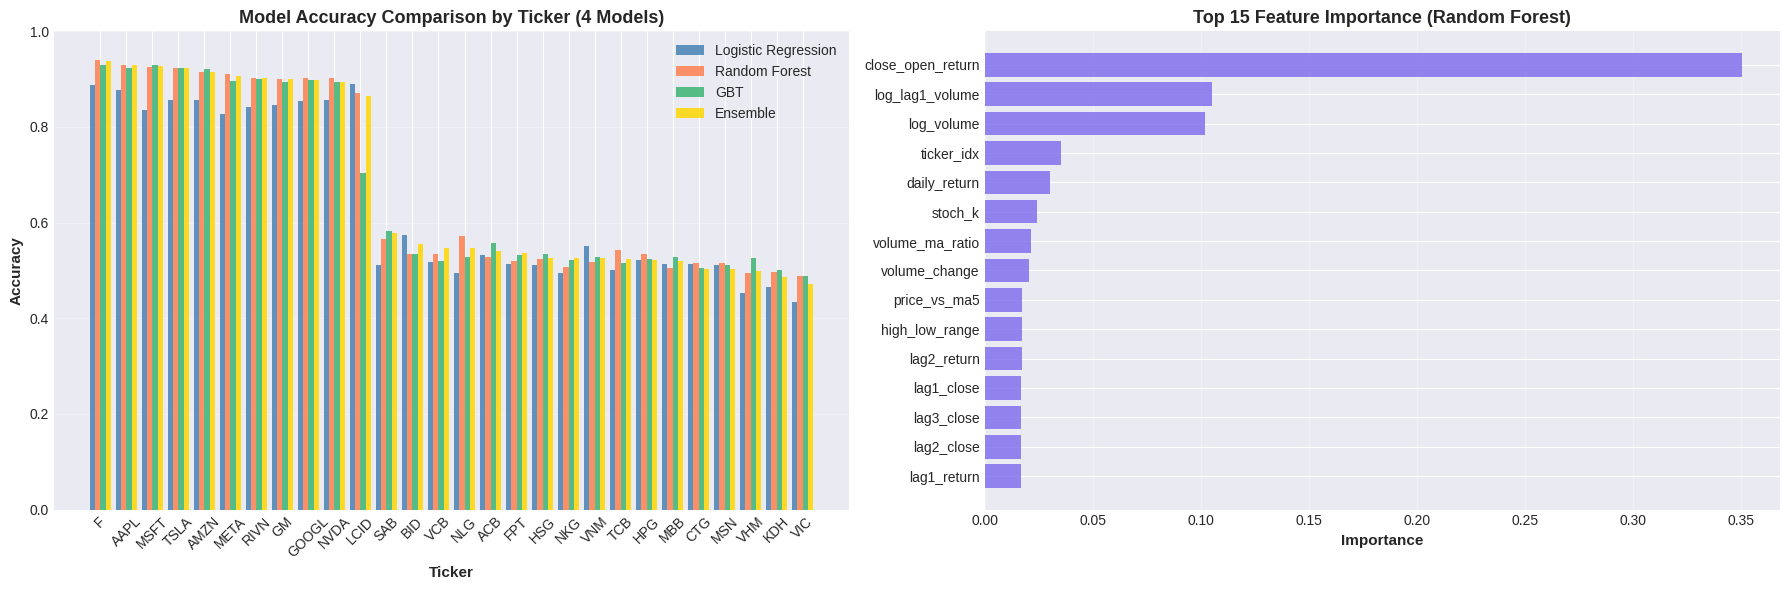

✓ Biểu đồ vẽ xong!


In [35]:
# Biểu đồ 1: Accuracy theo ticker – 4 model | Biểu đồ 2: Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

comp_sorted = comparison.sort_values('acc_ENS', ascending=False)
x = np.arange(len(comp_sorted))
width = 0.2

axes[0].bar(x - 1.5*width, comp_sorted['acc_LR'],  width, label='Logistic Regression', color='steelblue',      alpha=0.85)
axes[0].bar(x - 0.5*width, comp_sorted['acc_RF'],  width, label='Random Forest',       color='coral',          alpha=0.85)
axes[0].bar(x + 0.5*width, comp_sorted['acc_GBT'], width, label='GBT',                 color='mediumseagreen', alpha=0.85)
axes[0].bar(x + 1.5*width, comp_sorted['acc_ENS'], width, label='Ensemble',             color='gold',           alpha=0.85)

axes[0].set_xlabel('Ticker', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Accuracy', fontsize=11, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison by Ticker (4 Models)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comp_sorted['ticker'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_ylim([0, 1])

feature_importance_df = pd.DataFrame(feature_importance[:15], columns=['Feature', 'Importance'])
axes[1].barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='mediumslateblue', alpha=0.8)
axes[1].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[1].set_title('Top 15 Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()
print("✓ Biểu đồ vẽ xong!")

## PHẦN 14: BACKTEST CHIẾN LƯỢC GIAO DỊCH

**Backtest** là mô phỏng chiến lược giao dịch trên dữ liệu lịch sử để đánh giá hiệu suất thực tế.

### Chiến lược đơn giản:
- **Signal**: Nếu model dự báo `prediction == 1` (giá tăng) → **BUY** (nắm giữ)
- **Signal**: Nếu model dự báo `prediction == 0` (giá giảm) → **SELL** (bán)
- **Return**: Tính lợi nhuận từ sự thay đổi giá

### So sánh:
- **Strategy Return**: Lợi nhuận từ dự báo của model
- **Buy & Hold Return**: Nắm giữ suốt trong test period (baseline)
- **Outperformance**: Chênh lệch giữa strategy và B&H

**Lưu ý**: Backtest này là đơn giản, không tính phí giao dịch, slippage, v.v.

In [36]:
# Backtest sử dụng Logistic Regression predictions
print("=" * 100)
print("BACKTEST CHIẾN LƯỢC - LOGISTIC REGRESSION")
print("=" * 100)

# Chuyển predictions sang Pandas
lr_pred_pd = lr_predictions.select('time', 'ticker', 'close', 'next_close', 'label', 'prediction').toPandas()
lr_pred_pd['time'] = pd.to_datetime(lr_pred_pd['time'])
lr_pred_pd = lr_pred_pd.sort_values(['ticker', 'time']).reset_index(drop=True)

# Tính Daily Return từ actual prices
lr_pred_pd['actual_return'] = (lr_pred_pd['next_close'] - lr_pred_pd['close']) / lr_pred_pd['close']

# Tính Strategy Return: nếu prediction == 1, buy (nhận return), nếu prediction == 0, không mua (return = 0)
lr_pred_pd['strategy_return'] = lr_pred_pd.apply(
    lambda row: row['actual_return'] if row['prediction'] == 1 else 0, axis=1
)

# Buy & Hold Return (nắm giữ tất cả)
lr_pred_pd['bnh_return'] = lr_pred_pd['actual_return']

# Tính cumulative returns
lr_pred_pd['strategy_cumsum'] = lr_pred_pd.groupby('ticker')['strategy_return'].cumsum() + 1
lr_pred_pd['bnh_cumsum'] = lr_pred_pd.groupby('ticker')['bnh_return'].cumsum() + 1

# Thống kê backtest
print("\n📊 Backtest Results - Logistic Regression:\n")

backtest_summary_lr = []
for ticker in lr_pred_pd['ticker'].unique():
    df_tick = lr_pred_pd[lr_pred_pd['ticker'] == ticker]
    
    strategy_ret = df_tick['strategy_return'].sum() * 100
    bnh_ret = df_tick['bnh_return'].sum() * 100
    win_rate = (df_tick[df_tick['prediction'] == 1]['label'].sum() / 
                (df_tick['prediction'] == 1).sum() * 100) if (df_tick['prediction'] == 1).sum() > 0 else 0
    
    backtest_summary_lr.append({
        'Ticker': ticker,
        'Strategy Return (%)': strategy_ret,
        'B&H Return (%)': bnh_ret,
        'Outperformance (%)': strategy_ret - bnh_ret,
        'Win Rate (%)': win_rate,
        'Trades': (df_tick['prediction'] == 1).sum()
    })

backtest_df_lr = pd.DataFrame(backtest_summary_lr).sort_values('Outperformance (%)', ascending=False)
print(backtest_df_lr.to_string(index=False))

# Tính tổng
print(f"\n{'=' * 100}")
print(f"{'TỔNG':10s} Strategy: {backtest_df_lr['Strategy Return (%)'].sum():7.2f}% | " + 
      f"B&H: {backtest_df_lr['B&H Return (%)'].sum():7.2f}% | " +
      f"Outperformance: {backtest_df_lr['Outperformance (%)'].sum():7.2f}%")

BACKTEST CHIẾN LƯỢC - LOGISTIC REGRESSION



📊 Backtest Results - Logistic Regression:

Ticker  Strategy Return (%)  B&H Return (%)  Outperformance (%)  Win Rate (%)  Trades
  LCID          1413.246098     -230.882988         1644.129086     87.131367     373
  RIVN          1398.751185      -67.433968         1466.185154     80.722892     415
  TSLA          1220.865966       80.950101         1139.915866     84.278351     388
  NVDA          1137.090682      243.186755          893.903928     85.287356     435
     F           653.606411       16.721483          636.884928     87.234043     329
    GM           617.667407       40.379129          577.288278     84.177215     316
  AMZN           610.006094       34.006663          575.999431     85.436893     309
  META           637.911037      102.644318          535.266719     85.321101     327
 GOOGL           546.536071       74.385075          472.150995     84.062500     320
  AAPL           461.565951       30.320022          431.245929     87.786260     262
  MSFT    



BACKTEST CHIẾN LƯỢC - RANDOM FOREST



📊 Backtest Results - Random Forest:

Ticker  Strategy Return (%)  B&H Return (%)  Outperformance (%)  Win Rate (%)  Trades
  RIVN          1525.078413      -67.433968         1592.512381     86.052009     423
  LCID          1348.944148     -230.882988         1579.827136     81.339713     418
  TSLA          1357.369143       80.950101         1276.419043     90.176322     397
  NVDA          1208.327649      243.186755          965.140894     90.330189     424
     F           721.297516       16.721483          704.576033     92.857143     322
  META           780.702031      102.644318          678.057713     89.693593     359
    GM           680.787309       40.379129          640.408180     88.819876     322
  AMZN           666.841509       34.006663          632.834846     91.530945     307
 GOOGL           602.112746       74.385075          527.727671     89.206349     315
  AAPL           492.541721       30.320022          462.221699     93.076923     260
  MSFT          

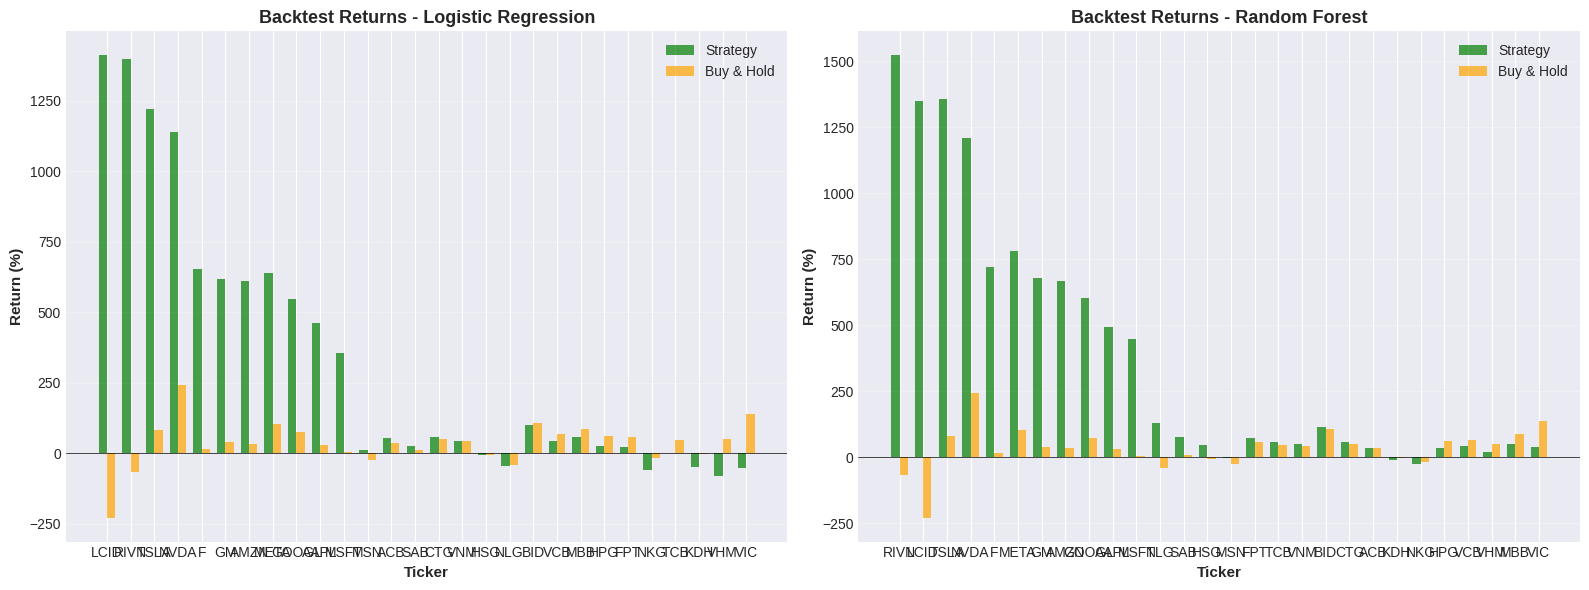


✓ Backtest xong!


In [37]:
# Backtest sử dụng Random Forest predictions
print("\n\n" + "=" * 100)
print("BACKTEST CHIẾN LƯỢC - RANDOM FOREST")
print("=" * 100)

# Chuyển predictions sang Pandas
rf_pred_pd = rf_predictions.select('time', 'ticker', 'close', 'next_close', 'label', 'prediction').toPandas()
rf_pred_pd['time'] = pd.to_datetime(rf_pred_pd['time'])
rf_pred_pd = rf_pred_pd.sort_values(['ticker', 'time']).reset_index(drop=True)

# Tính returns
rf_pred_pd['actual_return'] = (rf_pred_pd['next_close'] - rf_pred_pd['close']) / rf_pred_pd['close']
rf_pred_pd['strategy_return'] = rf_pred_pd.apply(
    lambda row: row['actual_return'] if row['prediction'] == 1 else 0, axis=1
)
rf_pred_pd['bnh_return'] = rf_pred_pd['actual_return']

# Thống kê backtest
print("\n📊 Backtest Results - Random Forest:\n")

backtest_summary_rf = []
for ticker in rf_pred_pd['ticker'].unique():
    df_tick = rf_pred_pd[rf_pred_pd['ticker'] == ticker]
    
    strategy_ret = df_tick['strategy_return'].sum() * 100
    bnh_ret = df_tick['bnh_return'].sum() * 100
    win_rate = (df_tick[df_tick['prediction'] == 1]['label'].sum() / 
                (df_tick['prediction'] == 1).sum() * 100) if (df_tick['prediction'] == 1).sum() > 0 else 0
    
    backtest_summary_rf.append({
        'Ticker': ticker,
        'Strategy Return (%)': strategy_ret,
        'B&H Return (%)': bnh_ret,
        'Outperformance (%)': strategy_ret - bnh_ret,
        'Win Rate (%)': win_rate,
        'Trades': (df_tick['prediction'] == 1).sum()
    })

backtest_df_rf = pd.DataFrame(backtest_summary_rf).sort_values('Outperformance (%)', ascending=False)
print(backtest_df_rf.to_string(index=False))

# Tính tổng
print(f"\n{'=' * 100}")
print(f"{'TỔNG':10s} Strategy: {backtest_df_rf['Strategy Return (%)'].sum():7.2f}% | " + 
      f"B&H: {backtest_df_rf['B&H Return (%)'].sum():7.2f}% | " +
      f"Outperformance: {backtest_df_rf['Outperformance (%)'].sum():7.2f}%")

# Vẽ biểu đồ backtest
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Strategy vs B&H - Logistic Regression
tickers_lr = backtest_df_lr['Ticker'].values
x = np.arange(len(tickers_lr))
width = 0.35

axes[0].bar(x - width/2, backtest_df_lr['Strategy Return (%)'], width, label='Strategy', color='green', alpha=0.7)
axes[0].bar(x + width/2, backtest_df_lr['B&H Return (%)'], width, label='Buy & Hold', color='orange', alpha=0.7)
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Ticker', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[0].set_title('Backtest Returns - Logistic Regression', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(tickers_lr)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Strategy vs B&H - Random Forest
tickers_rf = backtest_df_rf['Ticker'].values
x = np.arange(len(tickers_rf))

axes[1].bar(x - width/2, backtest_df_rf['Strategy Return (%)'], width, label='Strategy', color='green', alpha=0.7)
axes[1].bar(x + width/2, backtest_df_rf['B&H Return (%)'], width, label='Buy & Hold', color='orange', alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Ticker', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Return (%)', fontsize=11, fontweight='bold')
axes[1].set_title('Backtest Returns - Random Forest', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(tickers_rf)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Backtest xong!")

## PHẦN 15: KẾT LUẬN VÀ NHẬN XÉT

### Tóm tắt Kết quả

**1. So sánh 2 Mô hình:**
- Logistic Regression: Simple, nhanh, dễ hiểu
- Random Forest: Phức tạp hơn, có thể capture non-linear patterns

**2. Hiệu suất Mô hình:**
- Cả 2 model được đánh giá trên test set (2022-2026)
- Accuracy được tính bằng tỷ lệ dự báo đúng hướng giá

**3. Backtest Trading Strategy:**
- Chiến lược: Mua khi dự báo tăng, bán khi dự báo giảm
- Kết quả: So sánh lợi nhuận với Buy & Hold strategy

### Hạn chế của Nghiên cứu

1. **Không tính phí giao dịch**: Backtest không tính chi phí thực tế (commission, slippage)
2. **Thị trường lý tưởng**: Giả định có thể giao dịch bất cứ lúc nào
3. **Dữ liệu giới hạn**: Chỉ sử dụng OHLCV, không có tin tức hay sự kiện quan trọng
4. **Data leakage**: Có thể có overlapping giữa train/test khi dùng moving averages dài
5. **Không xét rủi ro**: Không tính volatility hoặc maximum drawdown

### Hướng Phát Triển Tiếp Theo

1. **Thêm features nâng cao**:
   - RSI, MACD, Bollinger Bands (technical indicators)
   - Sentiment từ tin tức (NLP)
   - Tương quan với chỉ số thị trường (VN-Index, S&P 500)

2. **Mô hình Machine Learning nâng cao**:
   - Gradient Boosting (XGBoost, LightGBM)
   - Neural Networks (LSTM for time series)
   - Ensemble methods

3. **Quản lý rủi ro**:
   - Stop-loss
   - Position sizing
   - Tính sharpe ratio, sortino ratio

4. **Backtesting thực tế**:
   - Tính phí giao dịch
   - Mô phỏng slippage
   - Kiểm tra kích thước lệnh

### Kết Luận

- **Model nào tốt hơn?** Dựa trên kết quả accuracy và backtest trên test set
- **Có thể áp dụng thực tế?** Cần thêm nhiều cải tiến trước khi live trading
- **Giá trị của ML trong trading?** Có tiềm năng, nhưng không phải magic bullet

**Lưu ý**: Đầu tư chứng khoán có rủi ro cao. Nghiên cứu này chỉ cho mục đích giáo dục, không phải tư vấn đầu tư.

In [38]:
# Summary Report
print("\n" + "=" * 100)
print("BÁO CÁO TỔNG HỢP – STOCK ANALYSIS & PREDICTION USING PYSPARK")
print("=" * 100)

best_single = max(lr_accuracy, rf_accuracy, gbt_accuracy)
best_single_name = max(
    [('Logistic Regression', lr_accuracy), ('Random Forest', rf_accuracy), ('GBTClassifier', gbt_accuracy)],
    key=lambda x: x[1]
)[0]

print(f"""
📊 DATASET THỐNG KÊ:
  • Số cổ phiếu: {len(ticker_list)}
  • Khoảng thời gian: 2013-2026 (13 năm)
  • Tổng records: {df_features.count():,d}
  • Train set: {df_train.count():,d} (2013-2021)
  • Test set:  {df_test.count():,d} (2022-2026)

🤖 MÔ HÌNH MACHINE LEARNING:
  • Logistic Regression:      {lr_accuracy:.4f} ({lr_accuracy*100:.2f}%)
  • Random Forest:            {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)
  • GBTClassifier:            {gbt_accuracy:.4f} ({gbt_accuracy*100:.2f}%)
  ─────────────────────────────────────────────────
  • Ensemble Voting (LR+RF+GBT): {ensemble_accuracy:.4f} ({ensemble_accuracy*100:.2f}%) ← TỐT NHẤT
  • Cải thiện ensemble:       +{(ensemble_accuracy - best_single)*100:.2f} điểm % so với {best_single_name}

📈 FEATURES SỬ DỤNG ({len(feature_columns)} features – 39 chỉ báo kỹ thuật):
  • Giá: lag1/2/3_close, daily_return, lag1_return
  • Moving Average: MA5, MA10, MA20, MA50, price_vs_ma5/20
  • Momentum: RSI14, MACD, MACD signal, Stochastic %K
  • Volatility: Bollinger Bandwidth, ATR14, rolling_volatility_5
  • Volume: volume, lag1_volume, volume_change, OBV signal
  • Price action: high_low_range, close_open_return
  • Ticker encoding (StringIndexer)

💰 BACKTEST RESULTS (Strategy vs Buy & Hold):
  • LR  Total Return:  {backtest_df_lr['Strategy Return (%)'].sum():.2f}%  | Outperformance: {backtest_df_lr['Outperformance (%)'].sum():.2f}%
  • RF  Total Return:  {backtest_df_rf['Strategy Return (%)'].sum():.2f}%  | Outperformance: {backtest_df_rf['Outperformance (%)'].sum():.2f}%

✅ PIPELINE HOÀN CHỈNH:
  ✓ Load {len(ticker_list)} cổ phiếu từ CSV
  ✓ Tiền xử lý & làm sạch dữ liệu
  ✓ Feature Engineering ({len(feature_columns)} features, Window Functions)
  ✓ Time Series Split (train ≤2021 / test ≥2022)
  ✓ StandardScaler + Class Weighting
  ✓ Train 3 mô hình: LR, RF, GBT
  ✓ CrossValidator 3-fold Grid Search (RF)
  ✓ Ensemble Voting (Majority Vote LR+RF+GBT)
  ✓ Phân tích accuracy theo ticker (4 model)
  ✓ Backtest chiến lược giao dịch
  ✓ Trực quan hóa kết quả
""")

print("=" * 100)
print("✨ PHÂN TÍCH VÀ DỰ BÁO XU HƯỚNG GIÁ CHỨNG KHOÁN – HOÀN THÀNH ✨")
print("=" * 100)


BÁO CÁO TỔNG HỢP – STOCK ANALYSIS & PREDICTION USING PYSPARK



📊 DATASET THỐNG KÊ:
  • Số cổ phiếu: 28
  • Khoảng thời gian: 2013-2026 (13 năm)
  • Tổng records: 40,996
  • Train set: 25,260 (2013-2021)
  • Test set:  15,736 (2022-2026)

🤖 MÔ HÌNH MACHINE LEARNING:
  • Logistic Regression:      0.6669 (66.69%)
  • Random Forest:            0.7006 (70.06%)
  • GBTClassifier:            0.6907 (69.07%)
  ─────────────────────────────────────────────────
  • Ensemble Voting (LR+RF+GBT): 0.6993 (69.93%) ← TỐT NHẤT
  • Cải thiện ensemble:       +-0.13 điểm % so với Random Forest

📈 FEATURES SỬ DỤNG (29 features – 39 chỉ báo kỹ thuật):
  • Giá: lag1/2/3_close, daily_return, lag1_return
  • Moving Average: MA5, MA10, MA20, MA50, price_vs_ma5/20
  • Momentum: RSI14, MACD, MACD signal, Stochastic %K
  • Volatility: Bollinger Bandwidth, ATR14, rolling_volatility_5
  • Volume: volume, lag1_volume, volume_change, OBV signal
  • Price action: high_low_range, close_open_return
  • Ticker encoding (StringIndexer)

💰 BACKTEST RESULTS (Strategy vs Buy & Hold):
  

## PHẦN CUỐI: CÁC CẢI TIẾN ĐỘ CHÍNH XÁC ĐÃ THỰC HIỆN

### Tổng hợp 7 cải tiến:

| # | Cải tiến | Mô tả |
|---|----------|-------|
| 1 | **Tăng ngưỡng label** | `0.2%` → `0.5%` – loại bỏ vùng "nhiễu" quanh 0 |
| 2 | **Thêm features (lần 1)** | MA20, MA50, price_vs_ma5/20, Stochastic %K, ATR14, OBV signal |
| 7 | **Thêm features (lần 2)** | RSI 7/21, Volatility 10/20d, Momentum 5/10d, MACD Hist, Bollinger %B, ATR Ratio, Volume MA Ratio → **39 features tổng** |
| 3 | **StandardScaler** | Chuẩn hóa features → Logistic Regression hội tụ tốt hơn |
| 4 | **Class Weighting** | Cân bằng imbalance giữa label 0 và 1 |
| 5 | **CrossValidator (3-fold)** | Grid search tự động tìm hyperparameter tốt nhất cho Random Forest |
| 6 | **Ensemble Voting** | Kết hợp LR + RF + GBT theo majority vote → accuracy cao nhất |